### Scenario 1: Montúfar (2014) Example with Hypercubes

This notebook compares the various sampling methods on the example from Montúfar (2014), where they construct a network whose linear regions are a grid of hypercubes.

#### Imports:

In [191]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import time
import scipy.stats.qmc as qmc
from pathlib import Path
from itertools import groupby
import scipy

#### Functions to generate/load point sets:

In [171]:
def iid_uniform_sample(num_points,dimensions,runs,lower_bounds, upper_bounds, seed):
    """Generates several iid uniform sample of points in a space of some dimension
    Args:
        num_points: the number of points to sample
        dimensions: the dimension of the space to sample from
        runs: the number of independent samples to generate - corresponds to number of runs in an experiment
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        seed: a seed for reproducibility
    Returns:
        points: 3D array of shape (runs,num_points,dimensions) representing all the points across all the samples
    """

    rng = np.random.default_rng(seed)
    
    # Generate points in [0,1)^d
    points = rng.uniform(size=(runs,num_points,dimensions))
    
    # Map points to desired rectangular region
    points = lower_bounds + (upper_bounds - lower_bounds)*points

    # Map to torch tensor
    points = torch.tensor(points)
    
    return points

In [172]:
def halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed):
    """Generates several halton samples of points in a space of some dimension
    Args:
        num_points: the number of points to sample
        dimensions: the dimension of the space to sample from
        runs: the number of independent samples to generate - corresponds to number of runs in an experiment
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        seed: a seed for reproducibility
    Returns:
        points: 3D array of shape (runs, num_points, dimensions)
    """

    points = np.empty((runs,num_points,dimensions))
    
    # You can use the same rng for all the runs because the state will evolve every time you call qmc.Halton() again
    rng = np.random.default_rng(seed)
    for i in range(runs):
        sampler = qmc.Halton(d=dimensions,scramble=True,seed=rng)
        points[i,:,:] = sampler.random(num_points)

    points = points*(upper_bounds - lower_bounds) + lower_bounds

    # Convert to torch tensor for neural network processing
    points = torch.tensor(points)
    
    return points

In [173]:
def sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds,seed):
    """Generates several sobol samples of points with different sample sizes
    Args:
        sample_sizes: a list of sample sizes to use for the region counting
        dimensions: the dimension of the space to sample from
        runs: the number of independent samples to generate - corresponds to number of runs in an experiment
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        seed: a seed for reproducibility
    Returns:
        all_points: a list of 3D arrays of shape (runs, num_points, dimensions)
    """

    all_points = []

    rng = np.random.default_rng(seed)

    for i in range(len(sample_sizes)):
        
        points = np.empty((runs,sample_sizes[i],dimensions))
        
        for j in range(runs):
            
            sampler = qmc.Sobol(d=dimensions,scramble=True,seed=rng)
            points[j,:,:] = sampler.random(sample_sizes[i])

        points = points*(upper_bounds - lower_bounds) + lower_bounds

        # Convert to torch tensor so we can put through the neural network
        points = torch.tensor(points)
        
        all_points.append(points)

    return all_points

In [51]:
def load_blue_noise_points(path, lower_bound, upper_bound):
    """Formats the blue noise point sets in a way that they can be used for the experiments
    Args:
        path: location where the blue noise point sets are stored
        lower_bounds: lower bound for all dimensions to adjust blue noise point sets from [0,1]^d
        upper_bounds: upper bound for all dimensions to adjust blue noise point sets from [0,1]^d
    Returns:
        blue_noise_sets: a list of lists containing the blue noise points for each dimension
                         and sample size within that dimension
    """

    dir_path = Path(path)

    def get_metadata(path_obj):
        parts = path_obj.stem.split('_')
        return int(parts[3]),int(parts[2])

    sorted_file_paths = sorted(dir_path.glob('*.npy'),key=get_metadata)

    blue_noise_sets = []

    for dimension, group in groupby(sorted_file_paths, key = lambda p: get_metadata(p)[0]):
        lower_bounds = np.full(dimension,lower_bound)
        upper_bounds = np.full(dimension,upper_bound)
        sublist_data = []
        for file_path in group:
            point_set = lower_bounds + np.load(str(file_path),mmap_mode="r")*(upper_bounds-lower_bounds)
            point_set = torch.tensor(point_set)
            sublist_data.append(point_set)
        blue_noise_sets.append(sublist_data)

    return blue_noise_sets

In [174]:
def grid_sample(sample_sizes, dimensions, lower_bound, upper_bound):
    """Generates a sample of n=m^d points in a regular lattice
    Args:
        sample sizes: a list of values of m (the number of points on each axis to construct the grid)
        dimensions: d (the number of dimensions of the input space)
        lower_bound: the lower bound of the input space in each dimension
        upper_bound: the upper bound of the input space in each dimension
    Returns:
        grid_sample: the grid of points
    """

    samples = []

    for points_per_axis in sample_sizes:

        # Exclude the endpoint along each axis because we are looking at the number of regions in [0,1)^d with 1 excluded
        coordinate_arrays = [np.linspace(lower_bound,upper_bound,int(points_per_axis)) for i in range(dimensions)]
        meshes = np.meshgrid(*coordinate_arrays,indexing="ij")
        grid_sample = np.column_stack([m.ravel() for m in meshes])
        grid_sample = torch.tensor(grid_sample)
        grid_sample = torch.unsqueeze(grid_sample,dim=0)

        samples.append(grid_sample)

    return samples

Test function for uniform sample:

In [29]:
num_points = 10000
dimensions = 2
runs=100
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
seed=1
points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed=1)

In [30]:
print(points.shape)

torch.Size([100, 10000, 2])


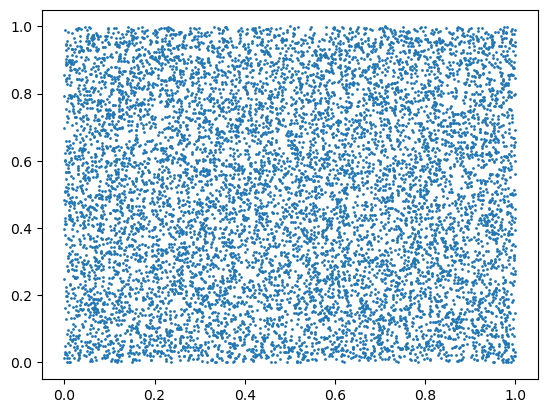

In [32]:
plt.scatter(points[0,:,0],points[0,:,1],s=1)

Test function for Halton sample:

In [78]:
num_points = 10000
dimensions = 2
runs=100
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
seed=1
points = halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed=1)

In [79]:
print(points.shape)

torch.Size([100, 10000, 2])


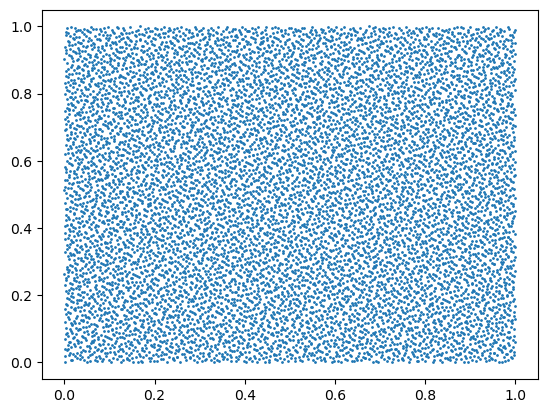

In [84]:
plt.scatter(points[0,:,0],points[0,:,1],s=1)

Test function for Sobol sample:

In [285]:
sample_sizes = [2**6,2**7,2**8,2**9]
dimensions = 2
runs=100
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
points = sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds)

In [295]:
first_set = points[3]

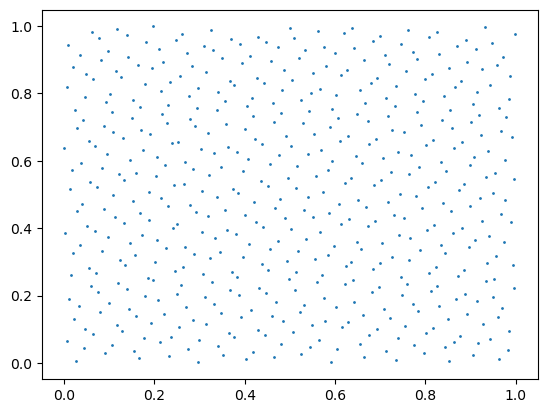

In [296]:
plt.scatter(first_set[5,:,0],first_set[5,:,1],s=1)

Test function to load blue noise point sets:

In [479]:
path = '/Users/gautamchauhan/Desktop/MSc Project Code/blue_noise_points_100_runs'
lower_bound = -1
upper_bound = 1
blue_noise_sets = load_blue_noise_points(path,lower_bound,upper_bound)

In [480]:
print(len(blue_noise_sets))

9


In [481]:
print(len(blue_noise_sets[0]))

10


In [514]:
blue_noise_2 = blue_noise_sets[0][4]

In [515]:
blue_noise_2.shape

torch.Size([100, 1024, 2])

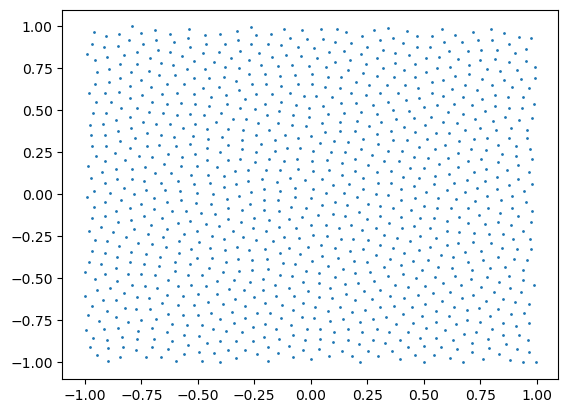

In [518]:
plt.scatter(blue_noise_2[1,:,0],blue_noise_2[1,:,1],s=1)

In [519]:
del blue_noise_sets

Test function to generate grid:

In [739]:
sample_sizes = [1,2,3,4,5]
dimensions = 4
lower_bound = -1
upper_bound = 1-1e-10

grid_samples = grid_sample(sample_sizes, dimensions, lower_bound, upper_bound)

In [740]:
grid = grid_samples[4]

In [741]:
print(grid.shape)

torch.Size([1, 625, 4])


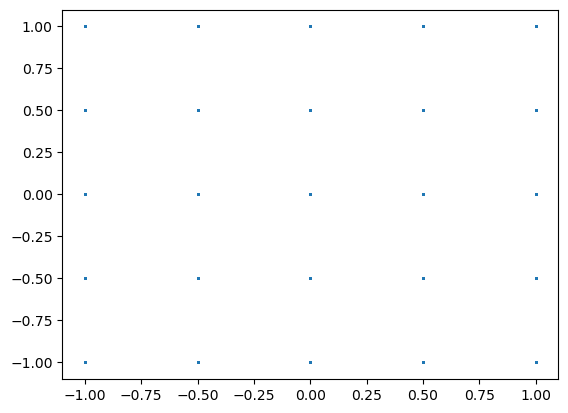

In [742]:
plt.scatter(grid[:,:,0],grid[:,:,1],s=1)

#### Code to set up MLP

In [3]:
class MLP(torch.nn.Module):
    def __init__(self,dimensions,neurons_per_hidden,custom_weights=None,custom_biases=None):
        """Set up the neural network model according to the specification given by parameters
        Args:
            dimensions: number of input dimensions
            neurons_per_hidden: 1D array or list containing widths of each layer
            custom_weights: None if Kaiming normal initialisation is to be used, otherwise a list of 2D torch tensors,
                            representing weight matrices to be used between each adjacent pair of layers
            custom_biases: None if Kaiming normal initialisation is to be used, otherwise a list of 1D torch tensors,
                            representing the bias of each neuron in each layer of the neural network
        """
        super().__init__()

        # Create a PyTorch list to store the layers and store the number of neurons per layer
        self.layers = torch.nn.ModuleList()
        self.architecture = neurons_per_hidden

        # Create first hidden layer using dimensions parameter
        hidden1 = torch.nn.Linear(dimensions, neurons_per_hidden[0], bias=True)
        self.layers.append(hidden1)
        self.layers.append(torch.nn.ReLU())
        
        # Create the remaining hidden layers
        for i in range(len(neurons_per_hidden)-1):
            hidden = torch.nn.Linear(neurons_per_hidden[i], neurons_per_hidden[i+1], bias=True)
            self.layers.append(hidden)
            self.layers.append(torch.nn.ReLU())

        # Set initial weights for all layers using user-input or Kaiming normal initialisation
        if custom_weights:
            with torch.no_grad():
                for i in range(len(self.layers)):
                    if isinstance(self.layers[i],torch.nn.Linear):
                        self.layers[i].weight.copy_(custom_weights[int(i/2)])
                        self.layers[i].bias.copy_(custom_biases[int(i/2)])
        else:
            generator = torch.Generator()
            generator.manual_seed(1)
            self.apply(lambda m: self.init_weights(m,generator))

    def init_weights(self, module, generator):
        """Initialise weights according to Kaiming normal distribution and biases according to a uniform distribution
        Args:
            module: the layer to be initialised
            generator: sets a random seed to ensure reproducibility of initial weights
        """
        if isinstance(module, torch.nn.Linear):
            torch.nn.init.kaiming_normal_(module.weight, nonlinearity="relu",generator=generator)
            torch.nn.init.uniform_(module.bias,a=-1.0,b=1,generator=generator)

    
    def forward(self,x):
        """Forward pass through the network to get the activations of each layer for a batch of data
        Args:
            x: a batch of inputs - 3D array of inputs of shape (number of runs, number of points, input dimension)
        Returns:
            activations: the activations of each neuron in each layer of the network,
                         as a 3D array of shape: (number of runs, number of points, total number of neurons)
        """
        x = x.float()
        for layer in self.layers:
            x = layer(x)
            # The layers are Linear, ReLU, Linear, ReLU, etc. Store activations after ReLU layers (>0 if on, =0 if off)
            if isinstance(layer,torch.nn.ReLU):
                # If we do not have the first layer, concatenate the activations along the last axis
                try:
                    activations = torch.cat((activations,x),axis=-1)
                # If we have the first layer, initialise the activations array
                except:
                    activations = x
        return activations

#### Code to count linear regions

Online region counting function which uses subsets of a larger sample (for Binomial Point Process/Halton Sequence):

In [4]:
def region_count_online(input_points,model,return_samples=False):
    """Count the number of unique linear regions in the input space of a MLP using a set of points distributed across the input space
    Args:
        points: torch tensor of points with shape (number of runs, number of points, dimensions)
        model: the neural network model we are analysing
        return_samples: Boolean flag telling you whether or not to return the samples corresponding with each region
    Returns:
        unique_counts: the number of regions counted using the sample points
        samples_by_region: a dictionary containing each unique region and the samples corresponding to it (or empty if return_samples=False)
    """

    # Set torch tensor for the number of regions counted in each run
    unique_counts = torch.zeros((input_points.shape[0],input_points.shape[1]))

    # Get array of activations with shape (number of runs, number of points, total number of neurons)
    activations = model(input_points)
    # For all the activations that are greater than 0, set the state to 1
    states = torch.zeros(activations.shape)
    states[activations>0] = 1
    states = states.to(torch.int64)
    
    # Get activation pattern by representing each series of activations as a base 2 number and converting to base 10
    cols = states.shape[-1]
    powers = 1 << torch.arange(cols - 1, -1, -1,dtype=torch.int64)
    activation_patterns = (states * powers).sum(dim=-1)

    # COUNT NUMBER OF UNIQUE REGIONS

    # Sort the activation patterns and get corresponding indices (stable = True ensures the first occurance is put first)
    sorted_t, indices = torch.sort(activation_patterns, dim=1, stable=True)
    
    # Find the first occurance of each new activation pattern as a Boolean Mask
    is_first_sorted = torch.ones_like(activation_patterns, dtype=torch.bool)
    is_first_sorted[:, 1:] = sorted_t[:, 1:] != sorted_t[:, :-1]
    
    # Put the true and false values back in their original order
    is_first_chronological = torch.empty_like(is_first_sorted)
    is_first_chronological.scatter_(dim=1, index=indices, src=is_first_sorted)
    
    # Count the number of true values up to each column using cumulative sum function in torch
    unique_counts = is_first_chronological.int().cumsum(dim=1)

    # GET ALL SAMPLES CORRESPONDING TO EACH REGION
    if return_samples:

        # Retrieve the unique patterns
        first_patterns = activation_patterns[0,:]
        unique_patterns = first_patterns[is_first_chronological[0,:]]
    
        samples_by_region = {}
        
        # Get the samples corresponding with each region
        for pattern in unique_patterns:
            input_points_first = input_points[0,:,:]
            samples_by_region[pattern] = input_points_first[activation_patterns[0,:]==pattern]

    else:

        samples_by_region = {}

    return unique_counts, samples_by_region

Offline region counting function which uses separate sample sizes (for Sobol Sequence/Gaussian Blue Noise)

In [5]:
def region_count_offline(input_points_list,model,return_samples=False):
    """Count the number of unique linear regions in the input space of a MLP using a set of points distributed across the input space
    Args:
        input_points_list: list of torch tensors of points with shape (number of runs, number of points, dimensions)
        model: the neural network model we are analysing
        return_samples: Boolean flag telling you whether or not to return the samples corresponding with each region
    Returns:
        unique_counts: the number of regions counted using the sample points
        samples_by_region: a dictionary containing each unique region and the samples corresponding to it (or empty if return_samples=False)
    """

    # Set torch tensor for the number of regions counted in each run
    runs = input_points_list[0].shape[0]
    unique_counts = torch.zeros((runs,len(input_points_list)))

    for i in range(len(input_points_list)):

        input_points = input_points_list[i]

        # Get array of activations with shape (number of runs, number of points, total number of neurons)
        activations = model(input_points)
        # For all the activations that are greater than 0, set the state to 1
        states = torch.zeros(activations.shape)
        states[activations>0] = 1
        states = states.to(torch.int64)
        
        # Get activation pattern by representing each series of activations as a base 2 number and converting to base 10
        cols = states.shape[-1]
        powers = 1 << torch.arange(cols - 1, -1, -1,dtype=torch.int64)
        activation_patterns = (states * powers).sum(dim=-1)
    
        # COUNT NUMBER OF UNIQUE REGIONS
    
        sorted_t, _ = torch.sort(activation_patterns, dim=1)
        changes = sorted_t[:, 1:] != sorted_t[:, :-1]
        counts_sample_size = changes.sum(dim=1) + 1

        unique_counts[:,i] = counts_sample_size

    # GET ALL SAMPLES CORRESPONDING TO EACH REGION
    if return_samples:

        # Retrieve the unique patterns
        unique_patterns = torch.unique(activation_patterns[0,:])
    
        samples_by_region = {}
        
        # Get the samples corresponding with each region
        for pattern in unique_patterns:
            input_points_final_samples = input_points_list[-1][0,:,:]
            samples_by_region[pattern] = input_points_final_samples[activation_patterns[0,:]==pattern]

    else:

        samples_by_region = {}

    return unique_counts, samples_by_region

#### Control Examples

**Simple Example Network from first presentation**

1. Uniform Samples

In [283]:
num_points = 10000
dimensions = 2
neurons_per_hidden = [2]
runs = 50
custom_weights = [torch.tensor([[1.0,-1.0],[1.0,1.0]])]
custom_biases = [torch.tensor([0.0,0.0])]
lower_bounds = np.full(dimensions,-1)
upper_bounds = np.full(dimensions,1)
seed = 1

model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)
unique_counts, samples_by_region = region_count_online(points,model,return_samples=True)

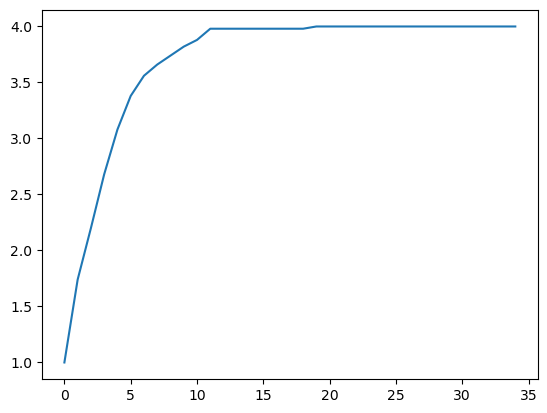

In [284]:
x = np.arange(35)
plt.plot(x,torch.mean(unique_counts.float(),axis=0)[:35])

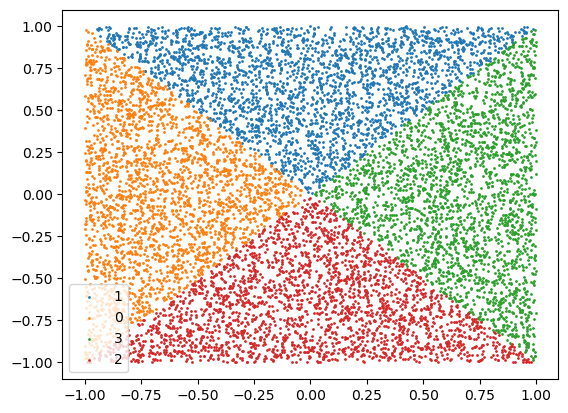

In [285]:
for key in samples_by_region.keys():
    samples = samples_by_region[key]
    plt.scatter(samples[:,0],samples[:,1],label=f"{key}",s=1)
plt.legend()

2. Halton Samples

In [291]:
num_points = 10000
dimensions = 2
neurons_per_hidden = [2]
runs = 50
custom_weights = [torch.tensor([[1.0,-1.0],[1.0,1.0]])]
custom_biases = [torch.tensor([0.0,0.0])]
lower_bounds = np.full(dimensions,-1)
upper_bounds = np.full(dimensions,1)
seed = 1

model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
points = halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)
unique_counts, samples_by_region = region_count_online(points,model,return_samples=True)

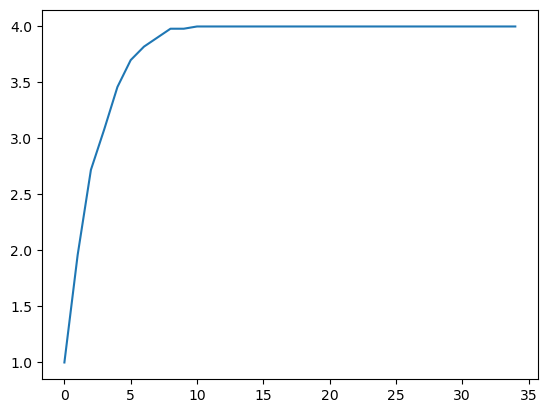

In [292]:
x = np.arange(35)
plt.plot(x,torch.mean(unique_counts.float(),axis=0)[:35])

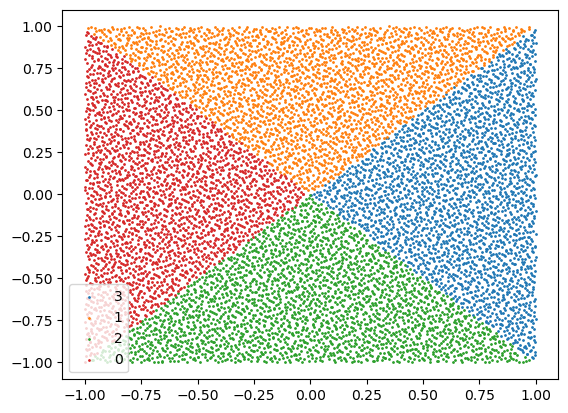

In [293]:
for key in samples_by_region.keys():
    samples = samples_by_region[key]
    plt.scatter(samples[:,0],samples[:,1],label=f"{key}",s=1)
plt.legend()

3. Sobol Samples

In [309]:
sample_sizes = [2**2,2**3,2**4,2**5,2**6,2**7,2**8,2**9,2**10,2**11,2**12,2**13]
dimensions = 2
neurons_per_hidden = [2]
runs = 50
custom_weights = [torch.tensor([[1.0,-1.0],[1.0,1.0]])]
custom_biases = [torch.tensor([0.0,0.0])]
lower_bounds = np.full(dimensions,-1)
upper_bounds = np.full(dimensions,1)
seed = 1

model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
points = sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds)
unique_counts, samples_by_region = region_count_offline(points,model,return_samples=True)

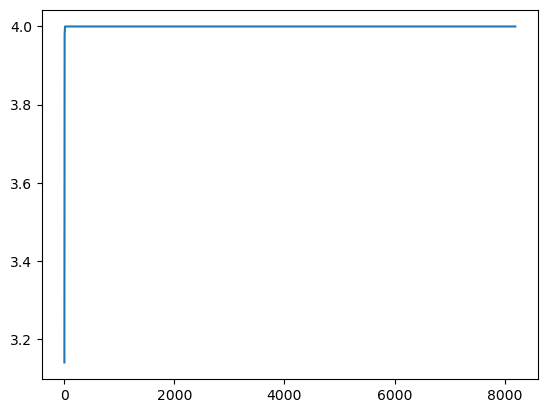

In [311]:
plt.plot(sample_sizes,torch.mean(unique_counts.float(),axis=0))

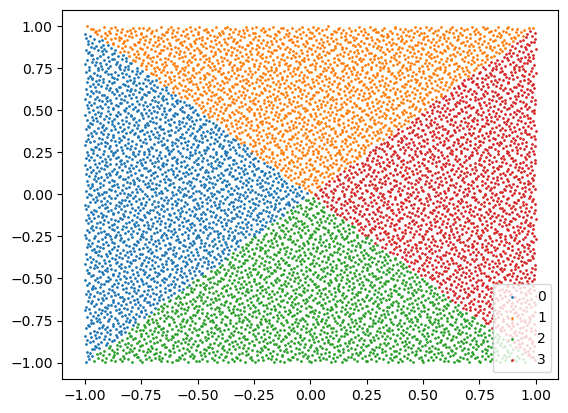

In [312]:
for key in samples_by_region.keys():
    samples = samples_by_region[key]
    plt.scatter(samples[:,0],samples[:,1],label=f"{key}",s=1)
plt.legend()

**Network from Bounding and Counting**

1. Uniform Samples

In [334]:
num_points = 50000
dimensions = 2
neurons_per_hidden = [2,2,2]
runs = 50
custom_weights = [torch.tensor([[-1.0,1.0],[1.0,1.0]]), torch.tensor([[-1.0,-3.0],[-3.0,-1.0]]),torch.tensor([[1.0,3.0],[3.0,1.0]])]
custom_biases = [torch.tensor([0.0,-4.0]),torch.tensor([4.0,4.0]),torch.tensor([-4.0,-4.0])]
lower_bounds = np.array([-0.5,-0.5])
upper_bounds = np.array([4.5,4.5])
seed = 1

model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)
unique_counts, samples_by_region = region_count_online(points,model,return_samples=True)

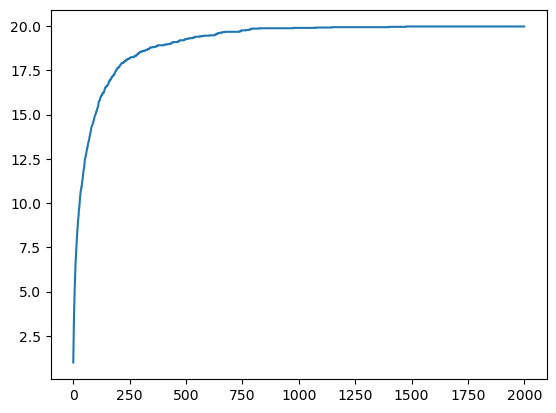

In [336]:
x = np.arange(2000)
plt.plot(x,torch.mean(unique_counts.float(),axis=0)[:2000])

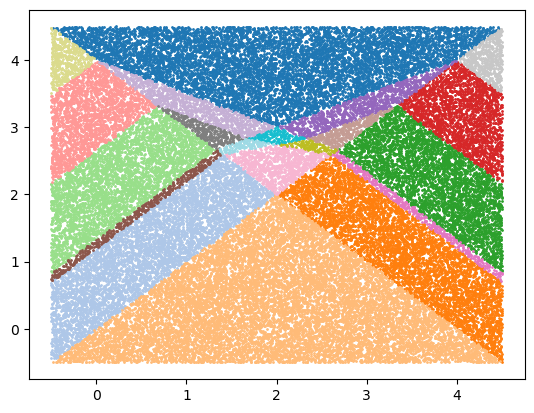

In [322]:
import matplotlib.pyplot as plt

cmap = plt.get_cmap('tab20') 

for i, (key, samples) in enumerate(samples_by_region.items()):
    color = cmap(i)
    plt.scatter(samples[:, 0], samples[:, 1], label=f"{key}", s=1, c=[color])

2. Halton Samples

In [337]:
num_points = 50000
dimensions = 2
neurons_per_hidden = [2,2,2]
runs = 50
custom_weights = [torch.tensor([[-1.0,1.0],[1.0,1.0]]), torch.tensor([[-1.0,-3.0],[-3.0,-1.0]]),torch.tensor([[1.0,3.0],[3.0,1.0]])]
custom_biases = [torch.tensor([0.0,-4.0]),torch.tensor([4.0,4.0]),torch.tensor([-4.0,-4.0])]
lower_bounds = np.array([-0.5,-0.5])
upper_bounds = np.array([4.5,4.5])
seed = 1

model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
points = halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)
unique_counts, samples_by_region = region_count_online(points,model,return_samples=True)

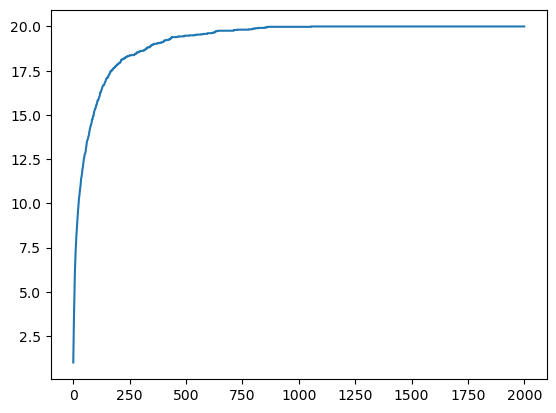

In [339]:
x = np.arange(2000)
plt.plot(x,torch.mean(unique_counts.float(),axis=0)[:2000])

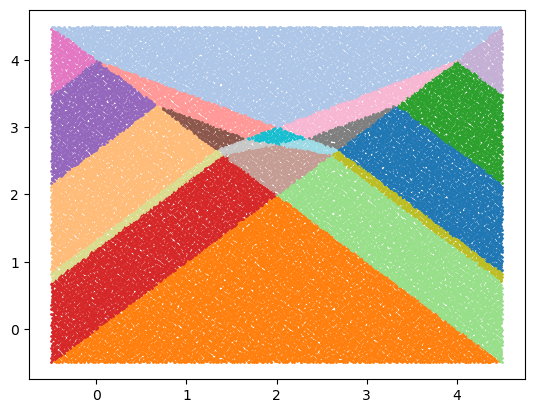

In [325]:
import matplotlib.pyplot as plt

cmap = plt.get_cmap('tab20') 

for i, (key, samples) in enumerate(samples_by_region.items()):
    color = cmap(i)
    plt.scatter(samples[:, 0], samples[:, 1], label=f"{key}", s=1, c=[color])

3. Sobol samples

In [340]:
sample_sizes = [2**2,2**3,2**4,2**5,2**6,2**7,2**8,2**9,2**10,2**11,2**12,2**13,2**14,2**15]
dimensions = 2
neurons_per_hidden = [2,2,2]
runs = 50
custom_weights = [torch.tensor([[-1.0,1.0],[1.0,1.0]]), torch.tensor([[-1.0,-3.0],[-3.0,-1.0]]),torch.tensor([[1.0,3.0],[3.0,1.0]])]
custom_biases = [torch.tensor([0.0,-4.0]),torch.tensor([4.0,4.0]),torch.tensor([-4.0,-4.0])]
lower_bounds = np.array([-0.5,-0.5])
upper_bounds = np.array([4.5,4.5])
seed = 1

model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
points = sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds)
unique_counts, samples_by_region = region_count_offline(points,model,return_samples=True)

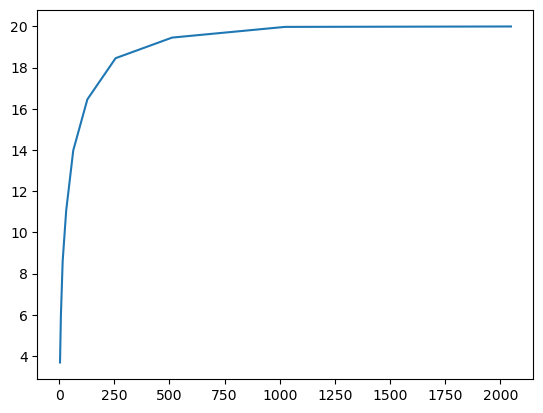

In [341]:
plt.plot(sample_sizes[:10],torch.mean(unique_counts.float(),axis=0)[:10])

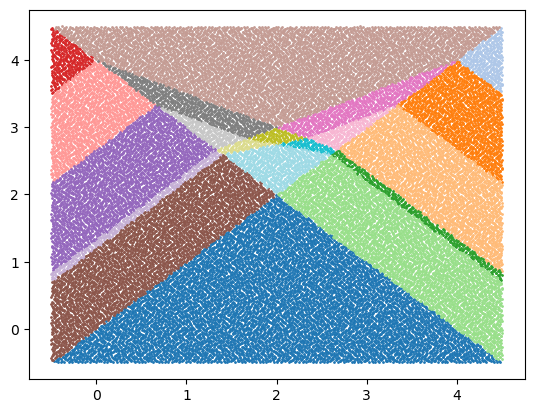

In [342]:
import matplotlib.pyplot as plt

cmap = plt.get_cmap('tab20') 

for i, (key, samples) in enumerate(samples_by_region.items()):
    color = cmap(i)
    plt.scatter(samples[:, 0], samples[:, 1], label=f"{key}", s=1, c=[color])

**RESULT**: all controls have passed

#### Example Networks

a) Network: 
- $n_0 = 4$ dimensional input
- 1 hidden layer of $40$ neurons divided into $p=10$ neuron blocks by the weights
- Exact count of regions = $p^{n_0} = 10^4 = 10000$

1. Use uniformly distributed sample points

In [21]:
num_points = 1000000
dimensions = 4
runs = 100
neurons_per_hidden = [40]
custom_weights = [torch.tensor([[1,0,0,0] for i in range(10)] + [[0,1,0,0] for i in range(10)]+[[0,0,1,0] for i in range(10)]+[[0,0,0,1]
                              for i in range(10)])]
custom_biases = [torch.tensor(np.tile([-i/10 for i in range(10)],4))]
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
rng = np.random.default_rng(seed=10)

model = MLP_2(dimensions,neurons_per_hidden,custom_weights,custom_biases)
uniform_sample = torch.tensor(rng.uniform(0,1,size=(runs, num_points, dimensions)))
start_time = time.time()
unique_counts, samples_by_region = region_count_2(uniform_sample,model,return_samples=False)
end_time = time.time()
print(end_time - start_time)

64.98533487319946


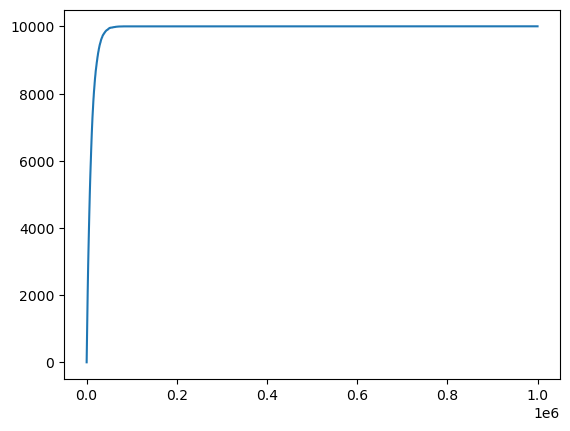

In [22]:
x = np.arange(1000000)
plt.plot(x,unique_counts[0,:1000000])

In [23]:
variances = torch.var(unique_counts.float(),axis=0)

Text(0, 0.5, 'Var($L_n$)')

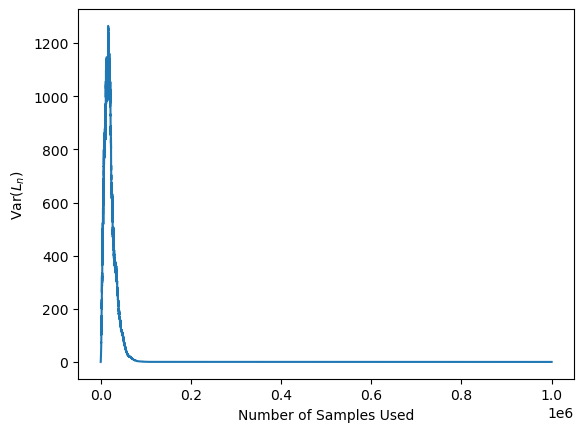

In [48]:
x = np.arange(1000000)
plt.plot(x,variances[:1000000])
plt.xlabel("Number of Samples Used")
plt.ylabel(r"Var($L_n$)")

2. Use Halton Sequence of points

In [25]:
# Generate 100 Halton Point Sets in 4 dimensions

runs = 100
num_points = 1000000
dimensions = 4

input_points = np.empty((runs,num_points,dimensions))

rng = np.random.default_rng(seed=10)
for i in range(runs):
    sampler = qmc.Halton(d=4,scramble=True,seed=rng)
    input_points[i,:,:] = sampler.random(1000000)

In [26]:
input_points = torch.tensor(input_points)

In [27]:
neurons_per_hidden = [40]
custom_weights = [torch.tensor([[1,0,0,0] for i in range(10)] + [[0,1,0,0] for i in range(10)]+[[0,0,1,0] for i in range(10)]+[[0,0,0,1]
                              for i in range(10)])]
custom_biases = [torch.tensor(np.tile([-i/10 for i in range(10)],4))]
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)

model = MLP_2(dimensions,neurons_per_hidden,custom_weights,custom_biases)
start_time = time.time()
halton_unique_counts, samples_by_region = region_count_2(input_points,model,return_samples=False)
end_time = time.time()
print(end_time - start_time)

61.892921686172485


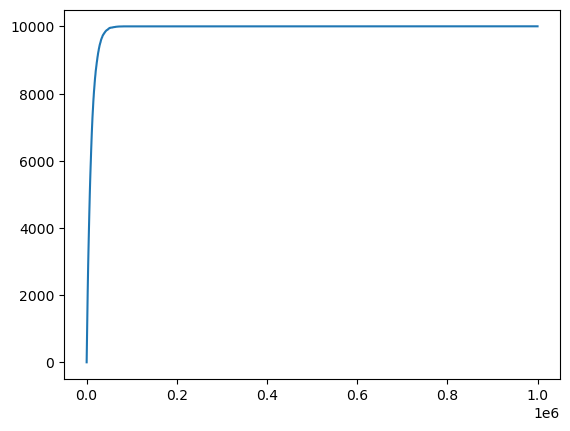

In [28]:
x = np.arange(1000000)
plt.plot(x,unique_counts[0,:])

In [38]:
halton_variances = torch.var(halton_unique_counts.float(),axis=0)

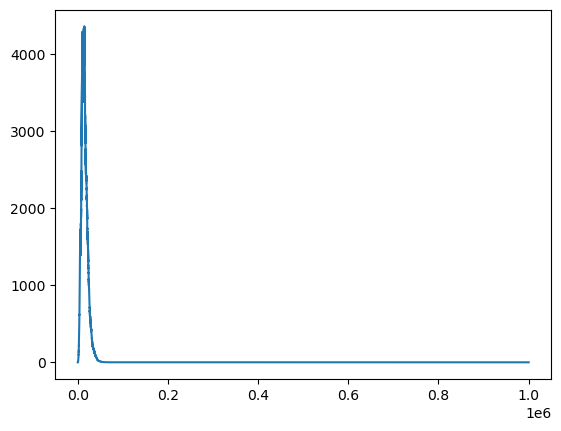

In [39]:
plt.plot(x,halton_variances)

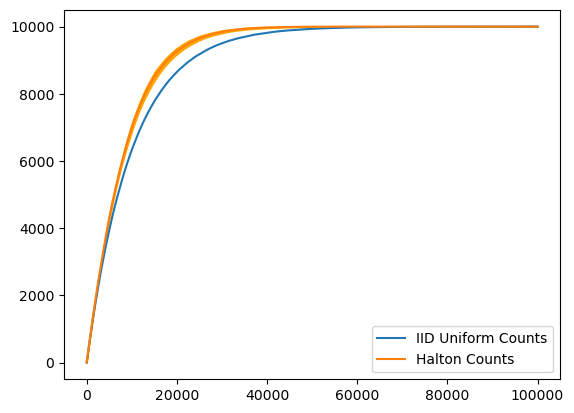

In [47]:
plt.plot(x[:100000],torch.mean(unique_counts[:,:100000].float(),axis=0),label="IID Uniform Counts")
plt.plot(x[:100000],torch.mean(halton_unique_counts[:,:100000].float(),axis=0),label="Halton Counts")
plt.fill_between(x[:100000],torch.mean(halton_unique_counts[:,:100000].float(),axis=0)-2*torch.sqrt(halton_variances[:100000]),torch.mean(halton_unique_counts[:,:100000].float(),axis=0)+2*torch.sqrt(halton_variances[:100000]),color="orange")
plt.legend()

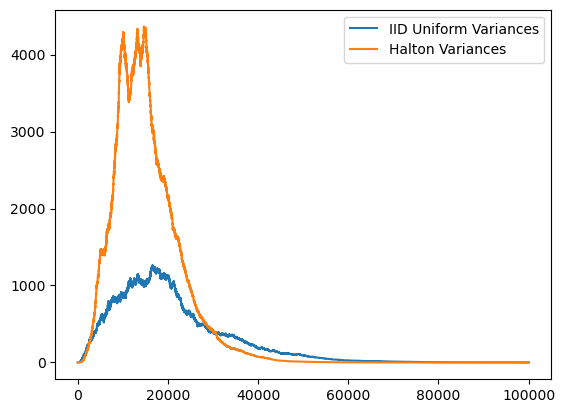

In [40]:
plt.plot(x[:100000],variances[:100000],label="IID Uniform Variances")
plt.plot(x[:100000],halton_variances[:100000],label="Halton Variances")
plt.legend()

b) Network: 
- $n_0 = 3$ dimensional input
- 30 hidden units partitioned into 3 subsets of size $p=10$
- Exact number of regions = $p^{n_0} = 10^3=1000$

In [50]:
num_points = 1000000
dimensions = 3
runs = 100
neurons_per_hidden = [30]
custom_weights = [torch.tensor([[1,0,0] for i in range(10)] + [[0,1,0] for i in range(10)]+[[0,0,1] for i in range(10)])]
custom_biases = [torch.tensor(np.tile([-i/10 for i in range(10)],3))]
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
rng = np.random.default_rng(seed=10)

model = MLP_2(dimensions,neurons_per_hidden,custom_weights,custom_biases)
uniform_sample = torch.tensor(rng.uniform(0,1,size=(runs, num_points, dimensions)))
start_time = time.time()
unique_counts, samples_by_region = region_count_2(uniform_sample,model,return_samples=False)
end_time = time.time()
print(end_time - start_time)

31.668053150177002


In [56]:
# Generate 100 Halton Point Sets in 4 dimensions

runs = 100
num_points = 1000000
dimensions = 3

input_points = np.empty((runs,num_points,dimensions))

rng = np.random.default_rng(seed=10)
for i in range(runs):
    sampler = qmc.Halton(d=3,scramble=True,seed=rng)
    input_points[i,:,:] = sampler.random(1000000)

In [59]:
input_points = torch.tensor(input_points)

In [62]:
neurons_per_hidden = [30]
custom_weights = [torch.tensor([[1,0,0] for i in range(10)] + [[0,1,0] for i in range(10)]+[[0,0,1] for i in range(10)])]
custom_biases = [torch.tensor(np.tile([-i/10 for i in range(10)],3))]
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)

model = MLP_2(dimensions,neurons_per_hidden,custom_weights,custom_biases)
start_time = time.time()
halton_unique_counts, samples_by_region = region_count_2(input_points,model,return_samples=False)
end_time = time.time()
print(end_time - start_time)

32.785593032836914


In [69]:
variances = torch.var(unique_counts[:,:10000].float(),axis=0)
halton_variances = torch.var(halton_unique_counts[:,:10000].float(),axis=0)

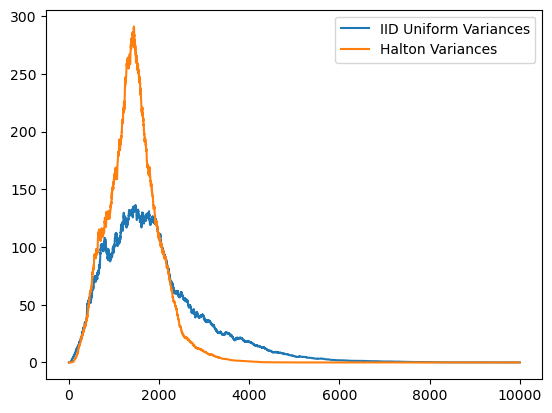

In [70]:
plt.plot(x[:10000],variances[:10000],label="IID Uniform Variances")
plt.plot(x[:10000],halton_variances[:10000],label="Halton Variances")
plt.legend()

In [85]:
mean = torch.mean(unique_counts[:,:10000].float(),axis=0)
halton_mean = torch.mean(halton_unique_counts[:,:10000].float(),axis=0)

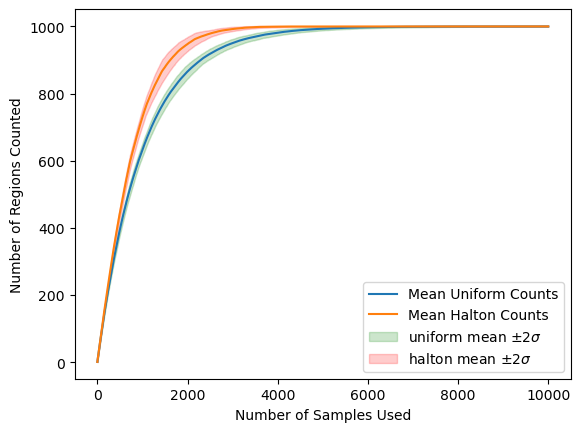

In [93]:
x = np.arange(1000000)
plt.plot(x[:10000],torch.mean(unique_counts[:,:10000].float(),axis=0),label="Mean Uniform Counts")
plt.plot(x[:10000],torch.mean(halton_unique_counts[:,:10000].float(),axis=0),label="Mean Halton Counts")
plt.fill_between(x[:10000],mean-2*torch.sqrt(variances[:10000]),mean+2*torch.sqrt(variances[:10000]),color="green",alpha=0.2,label=r"uniform mean $\pm 2 \sigma$")
plt.fill_between(x[:10000],halton_mean-2*torch.sqrt(halton_variances[:10000]),halton_mean+2*torch.sqrt(halton_variances[:10000]),color="red",alpha=0.2,label=r"halton mean $\pm 2 \sigma$")
plt.xlabel("Number of Samples Used")
plt.ylabel("Number of Regions Counted")
plt.legend()

c) Network:

- $n_0 = 2$ dimensional input
- 1 hidden layer of 16 neurons divided into subsets of size $p=8$ by the weights
- Exact number of regions is $p^{n_0}=8^2=16$

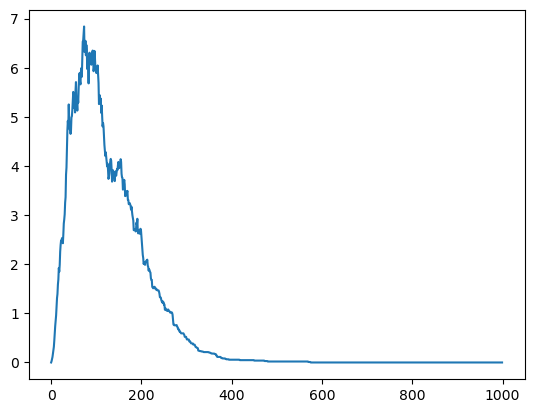

In [180]:
plt.plot(x,np.var(unique_counts.numpy(),axis=0))

Plot regions:

Text(0, 0.5, '$x_{2}$')

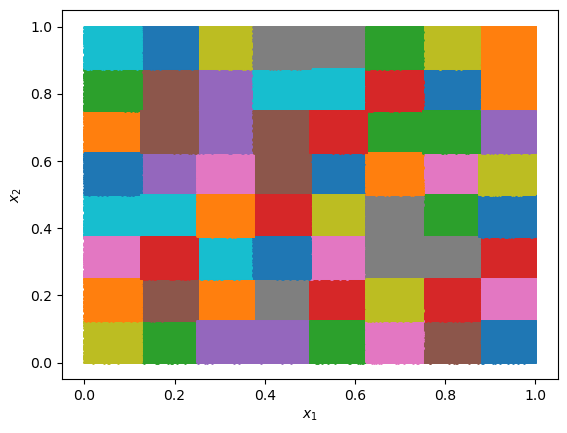

In [53]:
for pattern in samples_by_region.keys():
    samples = samples_by_region[pattern]
    plt.scatter(samples[:,0],samples[:,1],label=f"Pattern: {pattern}",s=1)
plt.xlabel(r"$x_{1}$")
plt.ylabel("$x_{2}$")

Estimate volumes of regions:

In [54]:
volumes = []
for pattern in samples_by_region.keys():
    samples = samples_by_region[pattern]
    volume_fraction = len(samples)/1000000
    volumes.append(volume_fraction)

(array([ 2., 10., 10., 15., 12.,  2.,  5.,  4.,  2.,  2.]),
 array([0.015403 , 0.0154582, 0.0155134, 0.0155686, 0.0156238, 0.015679 ,
        0.0157342, 0.0157894, 0.0158446, 0.0158998, 0.015955 ]),
 <BarContainer object of 10 artists>)

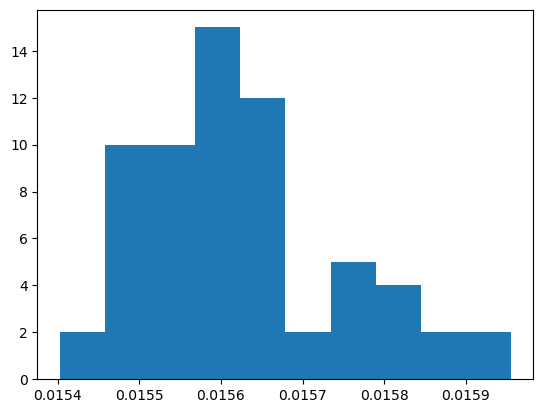

In [57]:
plt.hist(volumes,bins=10)

#### Formal Experiment Function

In [6]:
def experiment_2(sample_points,hidden_neurons,dimensions,runs=100,mode="online",return_samples=False):
    """Experiment for region counting using Montufar hypercubes example
    Args:
        sample_points: the sampling points used to count the regions - either numpy array (online counting) or list of arrays (offline)
        hidden_neurons: the number of neurons in the single hidden layer
        dimensions: the number of input dimensions
        runs: the number of times to rerun the experiment with different independent samples
        mode: whether to use the online/offline version of the region counting function
              online is used for BPP/Halton and offline for Sobol/Blue Noise
    Returns:
        unique_counts: 2D array of number of regions found after each number of samples for the different runs
    """

    p = int(np.floor(hidden_neurons/dimensions))
    
    # Set the network weights using p and dimension
    custom_weights = []
    for i in range(dimensions):
        segment_weights = [0 for i in range(dimensions)]
        segment_weights[i] = 1
        custom_weights += [segment_weights for _ in range(p)]
    custom_weights = [torch.tensor(custom_weights)]

    # Set the network biases using p and dimension
    custom_biases = [torch.tensor(np.tile([-i/p for i in range(p)], dimensions))]

    # Set up neural network - number of hidden neurons is p*n0 rather than hidden_neurons because the remainder neurons have weights
    # and biases set to 0 so they are essentially "dummy" neurons
    neurons_per_hidden = [p*dimensions]
    model = MLP(dimensions,neurons_per_hidden,custom_weights,custom_biases)
    if mode == "online":
        unique_counts, samples_by_region = region_count_online(sample_points,model,return_samples=return_samples)
    else:
        unique_counts, samples_by_region = region_count_offline(sample_points,model,return_samples=return_samples)

    return unique_counts, samples_by_region

#### Experiment 2A

**EXPERIMENT 2A:**
- neurons per hidden $= 40$
- dimensions $= 2,3,4,5,6,7,8,9,10$
- $p = 20,13,10,8,6,5,5,4,4$
- regions $= 400,2197,10000,32768,46656,78125,390625,262144,1048576$

In [102]:
num_points = 1000000
all_dimensions = [2,3,4,5,6,7,8,9,10]
runs = 100
seed = 1
hidden_neurons = 40

iid_counts = np.empty((max(all_dimensions),runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region susing those point sets and assign to the appropriate part of iid_counts
    unique_counts = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="online")
    unique_counts = unique_counts.detach().numpy()
    iid_counts[dimensions-2,:,:] = unique_counts

In [110]:
num_points = 1000000
all_dimensions = [2,3,4,5,6,7,8,9,10]
runs = 100
seed = 1
hidden_neurons = 40

halton_counts = np.empty((max(all_dimensions),runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region susing those point sets and assign to the appropriate part of iid_counts
    unique_counts = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="online")
    unique_counts = unique_counts.detach().numpy()
    halton_counts[dimensions-2,:,:] = unique_counts

Calculate summary statistics for Uniform and Halton and compare:

In [132]:
uniform_mean = np.mean(iid_counts,axis=1)
halton_mean = np.mean(halton_counts,axis=1)
uniform_variances = np.var(iid_counts,axis=1)
halton_variances = np.var(halton_counts,axis=1)

1. Maximum Variance against True Number of Regions for uniform

In [121]:
maximum_uniform_variances = np.max(uniform_variances,axis=1)[:-1]

In [176]:
maximum_halton_variances = np.max(halton_variances,axis=1)[:-1]

In [122]:
maximum_region_count = [400,2197,10000,32768,46656,78125,390625,262144,1048576]

Text(0, 0.5, '$\\log(\\text{Maximum Variance})$')

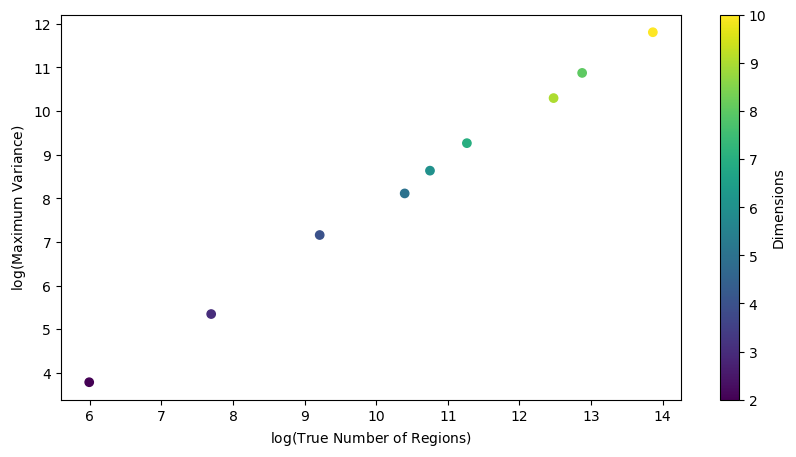

In [175]:
plt.figure(figsize=(10,5))
plt.scatter(np.log(maximum_region_count),np.log(maximum_uniform_variances),c=all_dimensions,cmap="viridis")
plt.colorbar(label="Dimensions")
plt.xlabel(r"$\log(\text{True Number of Regions})$")
plt.ylabel(r"$\log(\text{Maximum Variance})$")

In [401]:
coefs = np.polyfit(np.log(maximum_region_count),np.log(maximum_uniform_variances),deg=1)

We have a relationship of the form: $ \log y = m \log x + c \implies y = e^cx^m$

In [403]:
m = coefs[0]
c = coefs[1]

In [404]:
print("Power: " + str(m))

Power: 1.0282908372597692


In [405]:
print("Multiplier: " + str(np.exp(c)))

Multiplier: 0.08753335486070912


There is very likely a proportional relationship between the maximum variance and the true number of regions -> can we prove this?

2. Saturation point for Uniform and Halton

In [159]:
uniform_saturations = []
for i in range(len(all_dimensions)):
    try:
        first_time = np.where(uniform_mean[i,:] == maximum_region_count[i])[0][0]
        uniform_saturations.append(first_time)
    # Saturation point has not been reached
    except:
        uniform_saturations.append("N/A")


In [160]:
halton_saturations = []
for i in range(len(all_dimensions)):
    try:
        first_time = np.where(halton_mean[i,:] == maximum_region_count[i])[0][0]
        halton_saturations.append(first_time)
    # Saturation point has not been reached
    except:
        halton_saturations.append("N/A")

In [162]:
print("Uniform Saturation Points: ", uniform_saturations)
print("Halton Saturation Points: ", halton_saturations)

Uniform Saturation Points:  [5569, 27688, 146404, 463607, 804615, 'N/A', 'N/A', 'N/A', 'N/A']
Halton Saturation Points:  [1724, 14089, 85954, 331911, 582170, 'N/A', 'N/A', 'N/A', 'N/A']


Halton points consistently converge faster in number of linear regions than uniform points for this example

3. Maximum variance in terms of number of dimensions:

Text(0, 0.5, 'Maximum Variance')

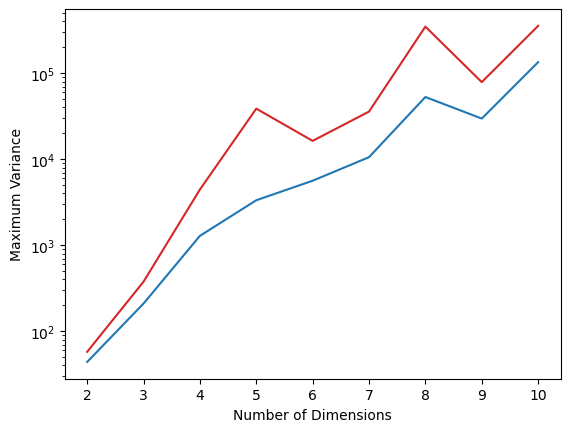

In [181]:
plt.semilogy(all_dimensions,maximum_uniform_variances,color="tab:blue",label="Uniform Points")
plt.semilogy(all_dimensions,maximum_halton_variances,color="tab:red",label="Halton Points")
plt.xlabel("Number of Dimensions")
plt.ylabel("Maximum Variance")

So for this example, using Halton points actually increases variance but this is offset by a significant reduction in bias, meaning the rate of convergence for the estimator using Halton Points is higher in this case.

Compare uniform sampling in online and offline cases:

In [426]:
sample_sizes = [2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15, 2**16, 2**17, 2**18, 2**19]
num_points = 1000000
dimensions = 5
runs = 100
hidden_neurons = 40

iid_counts_offline = np.empty((runs,len(sample_sizes)))

input_points = []
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)

for i in range(len(sample_sizes)):

    point_set = iid_uniform_sample(sample_sizes[i],dimensions,runs,lower_bounds,upper_bounds,seed=i)
    input_points.append(point_set)

# Count linear region susing those point sets and assign to the appropriate part of iid_counts
unique_counts = experiment_2(input_points,hidden_neurons,dimensions,runs,mode="offline")
unique_counts = unique_counts.detach().numpy()

In [427]:
mean_counts = np.mean(unique_counts,axis=0)

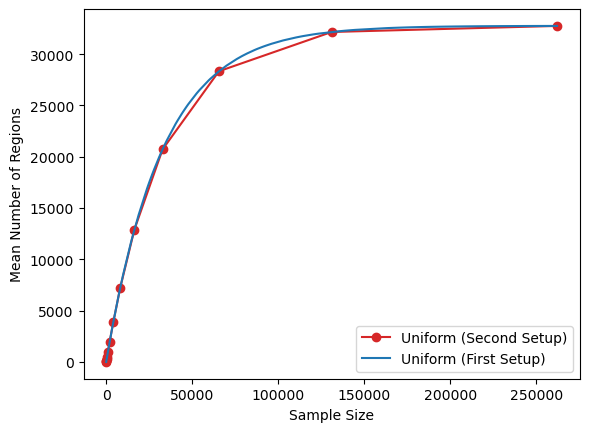

In [428]:
plt.plot(sample_sizes[:14],mean_counts[:14],color="tab:red",marker="o",label="Uniform (Second Setup)")
x = np.arange(2**18)
plt.plot(x,uniform_mean[3][:2**18],color="tab:blue",label="Uniform (First Setup)")
plt.xlabel("Sample Size")
plt.ylabel("Mean Number of Regions")
plt.legend()

In [429]:
variance_counts = np.var(unique_counts,axis=0)

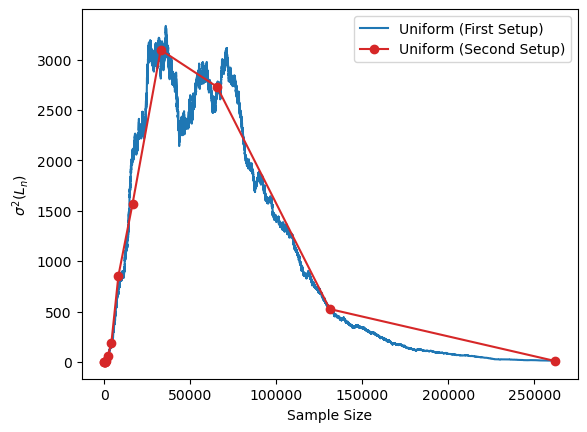

In [431]:
plt.plot(x,uniform_variances[3][:2**18],color="tab:blue",label="Uniform (First Setup)")
plt.plot(sample_sizes[:14],variance_counts[:14],color="tab:red",marker="o",label="Uniform (Second Setup)")
plt.xlabel("Sample Size")
plt.ylabel(r"$\sigma^2(L_n)$")
plt.legend()

Compare Halton Sampling in online and offline cases:

In [242]:
sample_sizes = [2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15, 2**16, 2**17, 2**18, 2**19]
num_points = 1000000
dimensions = 5
runs = 100
hidden_neurons = 40

iid_counts_offline = np.empty((runs,len(sample_sizes)))

input_points = []
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)

for i in range(len(sample_sizes)):

    point_set = halton_sample(sample_sizes[i],dimensions,runs,lower_bounds,upper_bounds,seed=i)
    input_points.append(point_set)

# Count linear region susing those point sets and assign to the appropriate part of iid_counts
unique_counts = experiment_2(input_points,hidden_neurons,dimensions,runs,mode="offline")
unique_counts = unique_counts.detach().numpy()

In [243]:
mean_counts = np.mean(unique_counts,axis=0)

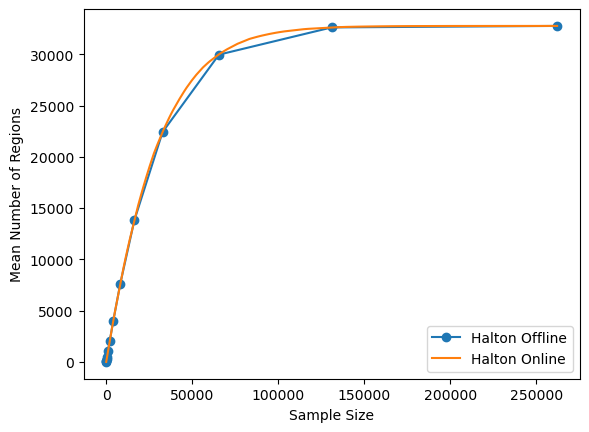

In [247]:
plt.plot(sample_sizes[:14],mean_counts[:14],marker="o",label="Halton Offline")
x = np.arange(2**18)
plt.plot(x,halton_mean[3][:2**18],label="Halton Online")
plt.xlabel("Sample Size")
plt.ylabel("Mean Number of Regions")
plt.legend()

In [248]:
variance_counts = np.var(unique_counts,axis=0)

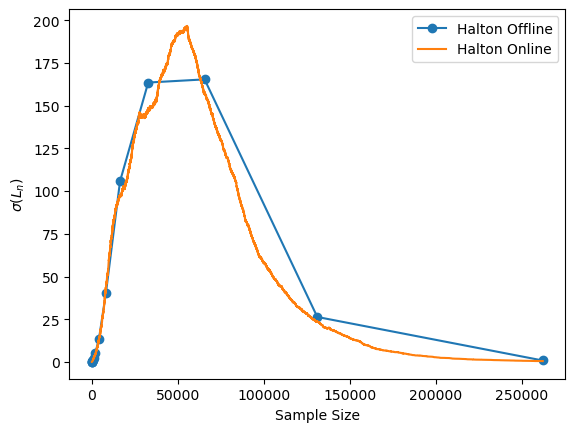

In [252]:
plt.plot(sample_sizes[:14],np.sqrt(variance_counts)[:14],marker="o",label="Halton Offline")
plt.plot(x,np.sqrt(halton_variances[3][:2**18]),label="Halton Online")
plt.xlabel("Sample Size")
plt.ylabel(r"$\sigma(L_n)$")
plt.legend()

Sobol sequences:

In [302]:
all_dimensions = [2,3,4,5,6,7,8,9,10]
sample_sizes = [2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15, 2**16, 2**17, 2**18, 2**19]
runs = 100
hidden_neurons = 40

sobol_counts = np.empty((max(all_dimensions),runs,len(sample_sizes)))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds)

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    sobol_counts[dimensions-2,:,:] = unique_counts

In [303]:
sobol_mean = np.mean(sobol_counts,axis=1)
sobol_variances = np.var(sobol_counts,axis=1)

Compare convergence rate and variance to uniform:

In [314]:
x = np.arange(2**19)

In [396]:
uniform_powers_mean = uniform_mean[:,sample_sizes]
uniform_powers_variances = uniform_variances[:,sample_sizes]

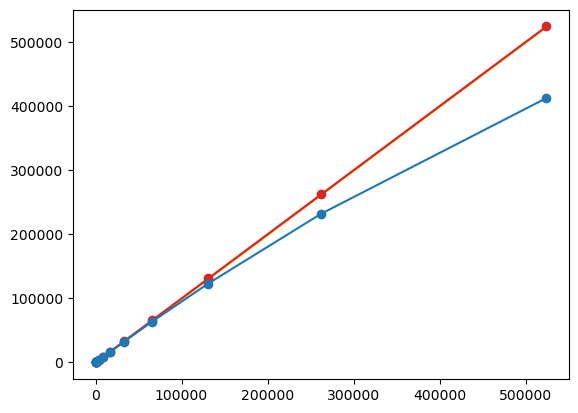

In [399]:
plt.plot(sample_sizes,sobol_mean[8,:],marker="o",color="tab:red")
plt.fill_between(sample_sizes,sobol_mean[8,:]-2*np.sqrt(sobol_variances[8,:]),sobol_mean[8,:]+2*np.sqrt(sobol_variances[8,:]),color="orange",alpha=1)
plt.plot(sample_sizes,uniform_powers_mean[8,:],marker="o")
plt.plot(sample_sizes,uniform_powers_mean[8,:]-2*np.sqrt(uniform_powers_variances[8,:]),uniform_powers_mean[8,:]+2*np.sqrt(uniform_powers_variances[8,:]),
         color="green",alpha=0)                                                        

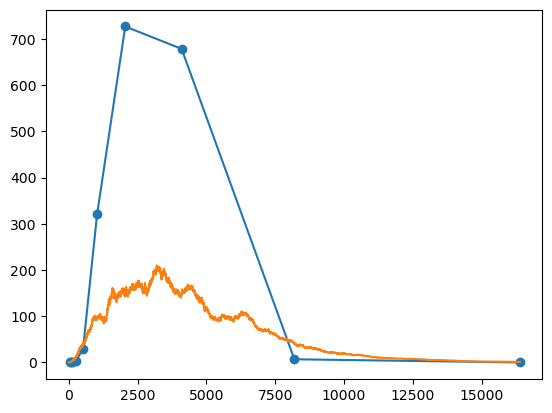

In [354]:
plt.plot(sample_sizes[:10],sobol_variances[1,:10],marker="o")
plt.plot(x[:2**14+1],uniform_variances[1,:2**14+1])

In [442]:
for i in range(2,11):
    print(np.floor(32/i)**i)

256.0
1000.0
4096.0
7776.0
15625.0
16384.0
65536.0
19683.0
59049.0


#### Experiment 2B

**EXPERIMENT 2B:**
- neurons per hidden $= 32$
- dimensions $= 2,3,4,5,6,7,8,9,10$
- $p = 20,13,10,8,6,5,5,4,4$
- regions $= 256,1000,4096,7776,15625,16384,65536,19683,59049$

1. Run uniform sampling:

In [15]:
num_points = 1000000
all_dimensions = [2,3,4,5,6,7,8,9,10]
runs = 100
seed = 1
hidden_neurons = 32

iid_counts = np.empty((max(all_dimensions),runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region susing those point sets and assign to the appropriate part of iid_counts
    unique_counts = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="online")
    unique_counts = unique_counts.detach().numpy()
    iid_counts[dimensions-2,:,:] = unique_counts

2. Plot uniform sampling graphs:

- Graph of Mean Count/Bias
- Graph of Variance
- Graph of Maximum Variance against True Number of Regions

In [17]:
uniform_mean_b = np.mean(iid_counts,axis=1)
uniform_variances_b = np.var(iid_counts,axis=1)

Text(0, 0.5, 'Bias($L_n$)')

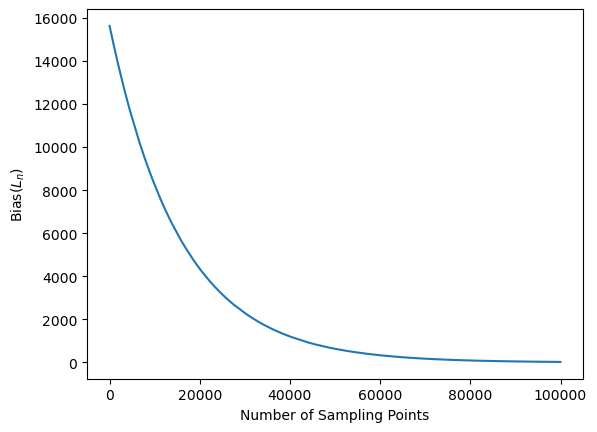

In [244]:
x = np.arange(100000)
plt.plot(x,15625-uniform_mean_b[4][:100000])
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"Bias($L_n$)")

Text(0, 0.5, '$\\sigma(L_n)$')

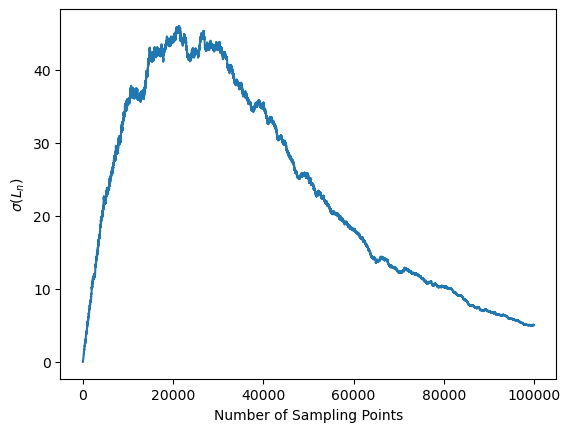

In [245]:
x = np.arange(100000)
plt.plot(x,np.sqrt(uniform_variances_b[4,:100000]))
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$\sigma(L_n)$")

In [47]:
maximum_uniform_variances_b = np.max(uniform_variances_b,axis=1)[:-1]

In [48]:
true_count = [np.floor(32/i)**i for i in range(2,11)]

In [49]:
coefs = np.polyfit(np.log(true_count),np.log(maximum_uniform_variances_b),deg=1)

In [50]:
m = coefs[0]
c = coefs[1]

In [51]:
print("Power: " + str(m))

Power: 1.0654683776077218


In [52]:
print("Multiplier: " + str(np.exp(c)))

Multiplier: 0.06585382282676971


Text(0, 0.5, '$\\log(\\text{Maximum Variance})$')

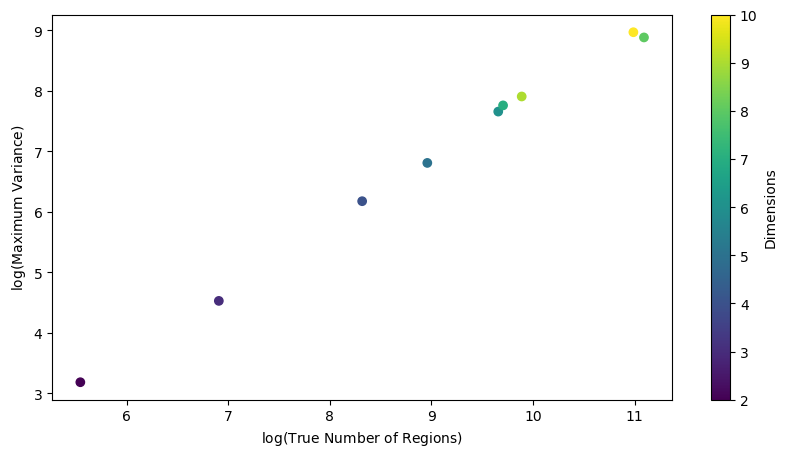

In [456]:
plt.figure(figsize=(10,5))
plt.scatter(np.log(true_count),np.log(maximum_uniform_variances_b),c=all_dimensions,cmap="viridis")
plt.colorbar(label="Dimensions")
plt.xlabel(r"$\log(\text{True Number of Regions})$")
plt.ylabel(r"$\log(\text{Maximum Variance})$")

3. Run:
- Halton Sampling
- Sobol Sampling
- Blue Noise Sampling
- Grid Sampling

In [11]:
num_points = 1000000
all_dimensions = [2,3,4,5,6,7,8,9,10]
runs = 100
seed = 1
hidden_neurons = 32

halton_counts_b = np.empty((max(all_dimensions),runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region susing those point sets and assign to the appropriate part of iid_counts
    unique_counts = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="online")
    unique_counts = unique_counts.detach().numpy()
    halton_counts_b[dimensions-2,:,:] = unique_counts

In [80]:
all_dimensions = [2,3,4,5,6,7,8,9,10]
sample_sizes = [2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15, 2**16, 2**17, 2**18, 2**19]
runs = 100
hidden_neurons = 32

sobol_counts_b = np.empty((max(all_dimensions),runs,len(sample_sizes)))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds)

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    sobol_counts_b[dimensions-2,:,:] = unique_counts

2. Plot Uniform/Halton/Sobol/Blue Noise/Grid Comparison Graphs

- Graphs showing variance against number of samples used for dimensions 2,4,6,8
- Graphs showing mean $\pm$ 2 sd against number of samples used for dimensions 2,4,6,8
- (maybe extra graphs/tables can go in the appendix)

In [13]:
halton_mean_b = np.mean(halton_counts_b,axis=1)
halton_variances_b = np.var(halton_counts_b,axis=1)

In [81]:
sobol_mean_b = np.mean(sobol_counts_b,axis=1)
sobol_variances_b = np.var(sobol_counts_b,axis=1)

2D:

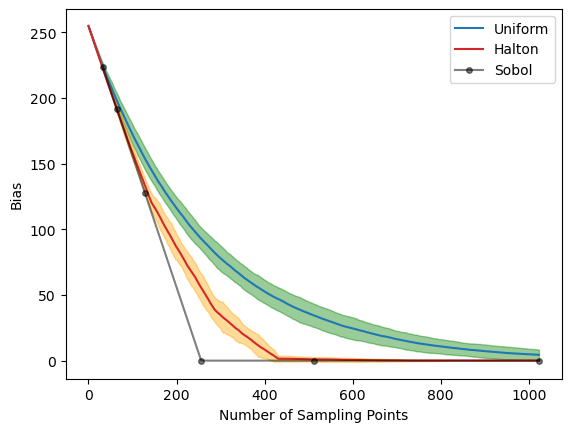

In [225]:
x = np.arange(2**10)
plt.plot(x,256-uniform_mean_b[0][:2**10],label="Uniform")
plt.fill_between(x,256-uniform_mean_b[0][:2**10]-2*np.sqrt(uniform_variances_b[0,:2**10]),
                 256-uniform_mean_b[0,:2**10]+2*np.sqrt(uniform_variances_b[0,:2**10]),color="green",alpha=0.4)
plt.plot(x,256-halton_mean_b[0][:2**10],color="tab:red",label="Halton")
plt.fill_between(x,256-halton_mean_b[0,:2**10]-2*np.sqrt(halton_variances_b[0,:2**10]),
                 256-halton_mean_b[0,:2**10]+2*np.sqrt(halton_variances_b[0,:2**10]),color="orange",alpha=0.4)
plt.plot(sample_sizes[:6],256-sobol_mean_b[0][:6],color="black",alpha=0.5,label="Sobol",marker="o",markersize=4)
plt.xlabel("Number of Sampling Points")
plt.ylabel("Bias")
plt.legend()

2D:

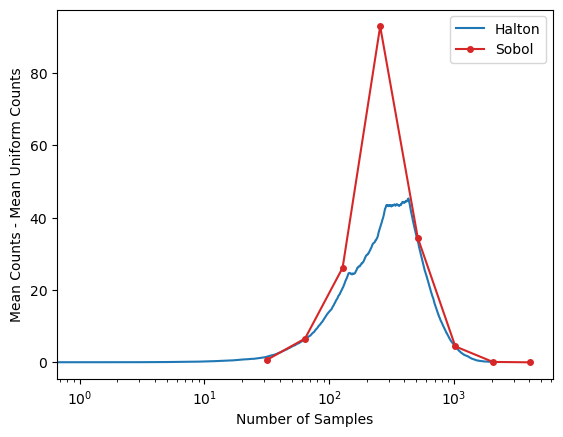

In [237]:
x = np.arange(1000000)
plt.semilogx(x[:2**11],halton_mean_b[0,:][:2**11]-uniform_mean_b[0,:][:2**11],label="Halton")
plt.semilogx(sample_sizes[:8],sobol_mean_b[0,:][:8]-uniform_mean_b[0,:][sample_sizes[:8]],marker="o",color="tab:red",label="Sobol",markersize=4)
plt.xlabel("Number of Samples")
plt.ylabel("Mean Counts - Mean Uniform Counts")
plt.legend()

4D:

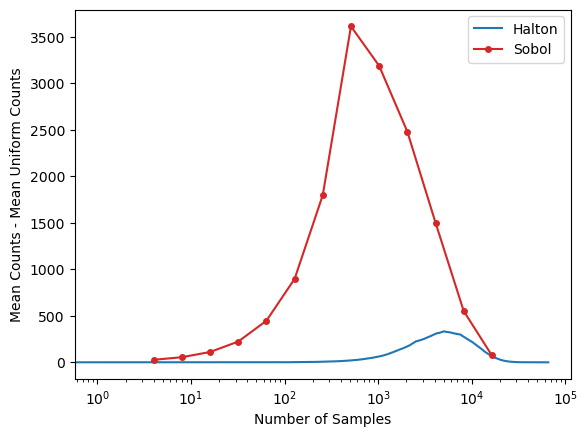

In [348]:
x = np.arange(1000000)
plt.semilogx(x[:2**16],halton_mean_b[2,:][:2**16]-uniform_mean_b[2,:][:2**16],label="Halton")
plt.semilogx(sample_sizes[:13],sobol_mean_b[2,:][:13]-uniform_mean_b[2,:][sample_sizes[:13]],marker="o",color="tab:red",label="Sobol",markersize=4)
plt.xlabel("Number of Samples")
plt.ylabel("Mean Counts - Mean Uniform Counts")
plt.legend()

6D:

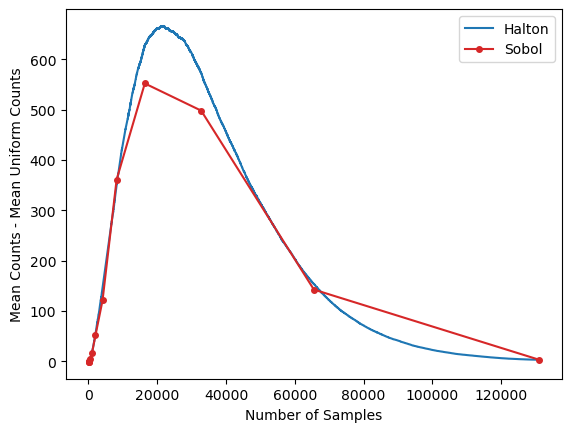

In [239]:
x = np.arange(1000000)
plt.plot(x[:2**17],halton_mean_b[4,:][:2**17]-uniform_mean_b[4,:][:2**17],label="Halton")
plt.plot(sample_sizes[:13],sobol_mean_b[4,:][:13]-uniform_mean_b[4,:][sample_sizes[:13]],marker="o",color="tab:red",label="Sobol",markersize=4)
plt.xlabel("Number of Samples")
plt.ylabel("Mean Counts - Mean Uniform Counts")
plt.legend()

8D:

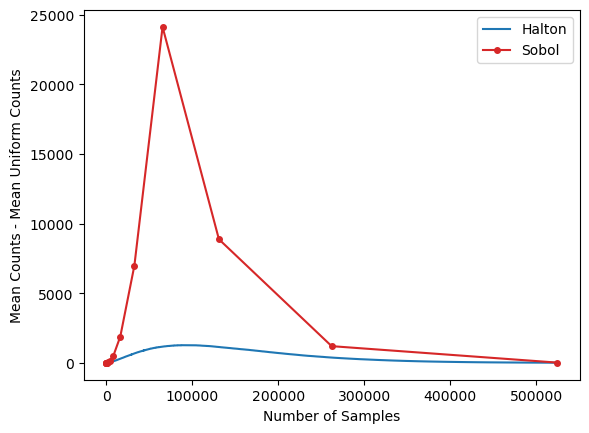

In [240]:
x = np.arange(1000000)
plt.plot(x[:2**19],halton_mean_b[6,:][:2**19]-uniform_mean_b[6,:][:2**19],label="Halton")
plt.plot(sample_sizes[:15],sobol_mean_b[6,:][:15]-uniform_mean_b[6,:][sample_sizes[:15]],marker="o",color="tab:red",label="Sobol",markersize=4)
plt.xlabel("Number of Samples")
plt.ylabel("Mean Counts - Mean Uniform Counts")
plt.legend()

#### Compare uniform sampling in online and offline cases

Use neural network setup with 24 hidden neurons

In [9]:
num_points = 50000
all_dimensions = [2,3,4,5,6,7,8,9,10]
runs = 100
seed = 1
hidden_neurons = 24

iid_counts_online = np.empty((max(all_dimensions),runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region susing those point sets and assign to the appropriate part of iid_counts
    unique_counts,samples_by_region = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="online")
    unique_counts = unique_counts.detach().numpy()
    iid_counts_online[dimensions-2,:,:] = unique_counts

In [20]:
sample_sizes = [2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]
num_points = 50000
dimensions = [2,3,4,5,6,7,8,9,10]
runs = 100
hidden_neurons = 24

iid_counts_offline = np.empty((max(dimensions),runs,len(sample_sizes)))

for j in range(len(dimensions)):

    input_points = []
    lower_bounds = np.full(dimensions[j],0)
    upper_bounds = np.full(dimensions[j],1)

    for i in range(len(sample_sizes)):
    
        point_set = iid_uniform_sample(sample_sizes[i],dimensions[j],runs,lower_bounds,upper_bounds,seed=i)
        input_points.append(point_set)
    
    # Count linear region susing those point sets and assign to the appropriate part of iid_counts
    unique_counts, samples_by_region = experiment_2(input_points,hidden_neurons,dimensions[j],runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()

    iid_counts_offline[j,:,:] = unique_counts

In [21]:
mean_online_counts = np.mean(iid_counts_online,axis=1)
mean_offline_counts = np.mean(iid_counts_offline,axis=1)

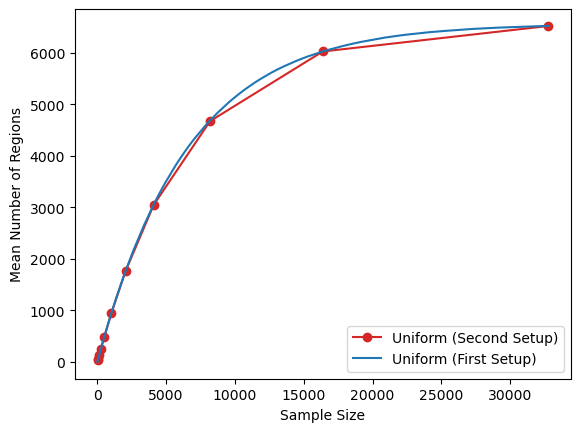

In [38]:
x = np.arange(2**15)
plt.plot(sample_sizes,mean_offline_counts[6,:2**15],color="tab:red",marker="o",label="Uniform (Second Setup)")
plt.plot(x,mean_online_counts[6][:2**15],color="tab:blue",label="Uniform (First Setup)")
plt.xlabel("Sample Size")
plt.ylabel("Mean Number of Regions")
plt.legend()

In [27]:
online_counts_variance = np.var(iid_counts_online,axis=1)
offline_counts_variance = np.var(iid_counts_offline,axis=1)

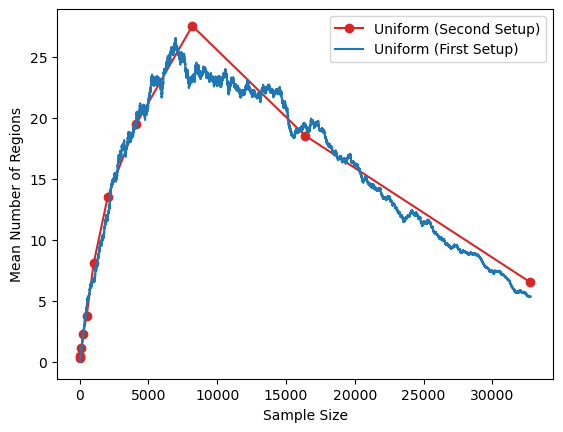

In [39]:
x = np.arange(2**15)
plt.plot(sample_sizes,np.sqrt(offline_counts_variance[6,:2**15]),color="tab:red",marker="o",label="Uniform (Second Setup)")
plt.plot(x,np.sqrt(online_counts_variance[6][:2**15]),color="tab:blue",label="Uniform (First Setup)")
plt.xlabel("Sample Size")
plt.ylabel("Mean Number of Regions")
plt.legend()

#### Scenario 1

**EXPERIMENT 2C:**
- neurons per hidden $= 24$
- dimensions $= 2,3,4,5,6,7,8,9,10$
- regions $= 144, 512, 1296, 1024, 4096, 2187, 6561, 512, 1024$

In [359]:
for i in range(2,11):
    print(np.floor(24/i)**i)

144.0
512.0
1296.0
1024.0
4096.0
2187.0
6561.0
512.0
1024.0


1. Uniform Sampling Graphs

- Bias against number of samples
- Standard deviation against number of samples
- Maximum Variance against true number of regions

In [176]:
num_points = 50000
all_dimensions = [2,3,4,5,6,7,8,9,10]
runs = 100
seed = 1
hidden_neurons = 24

iid_counts_c = np.empty((max(all_dimensions),runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = iid_uniform_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts, samples_by_region = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="online")
    unique_counts = unique_counts.detach().numpy()
    iid_counts_c[dimensions-2,:,:] = unique_counts

In [177]:
uniform_mean_c = np.mean(iid_counts_c,axis=1)
uniform_variances_c = np.var(iid_counts_c,axis=1)

In [178]:
x = np.arange(50000)

Text(0, 0.5, 'Bias($L_n$)')

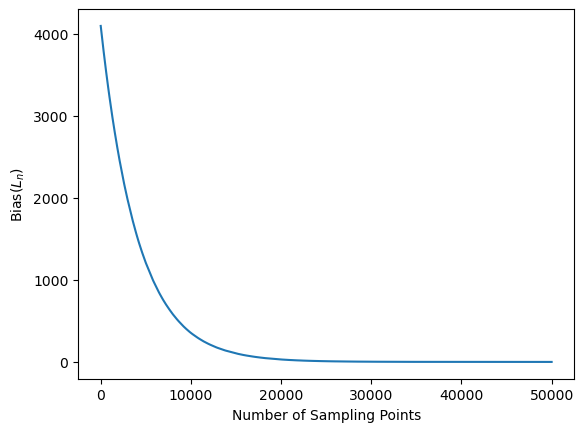

In [179]:
plt.plot(x,4096-uniform_mean_c[4])
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"Bias($L_n$)")

Text(0, 0.5, '$\\sigma(L_n)$')

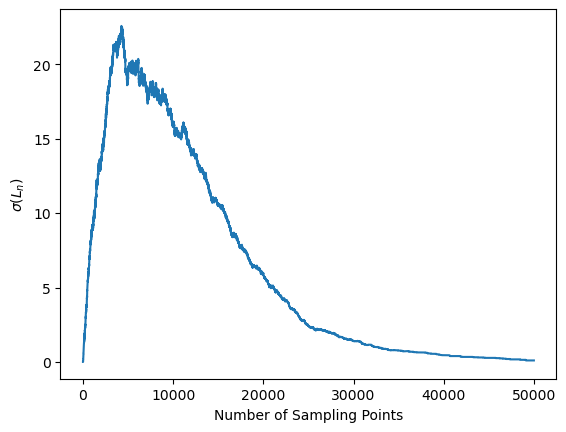

In [180]:
x = np.arange(50000)
plt.plot(x,np.sqrt(uniform_variances_c[4]))
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$\sigma(L_n)$")

In [181]:
maximum_uniform_variances_c = np.max(uniform_variances_c,axis=1)[:-1]

In [182]:
true_count = [np.floor(24/i)**i for i in range(2,11)]

In [183]:
coefs = np.polyfit(np.log(true_count),np.log(maximum_uniform_variances_c),deg=1)

In [184]:
m = coefs[0]
c = coefs[1]

In [185]:
print("Power: " + str(m))

Power: 1.0017433468977623


In [186]:
print("Multiplier: " + str(np.exp(c)))

Multiplier: 0.11185955566694404


In [187]:
print(c)

-2.1905111618212936


Text(0, 0.5, '$\\log(\\text{Maximum Variance})$')

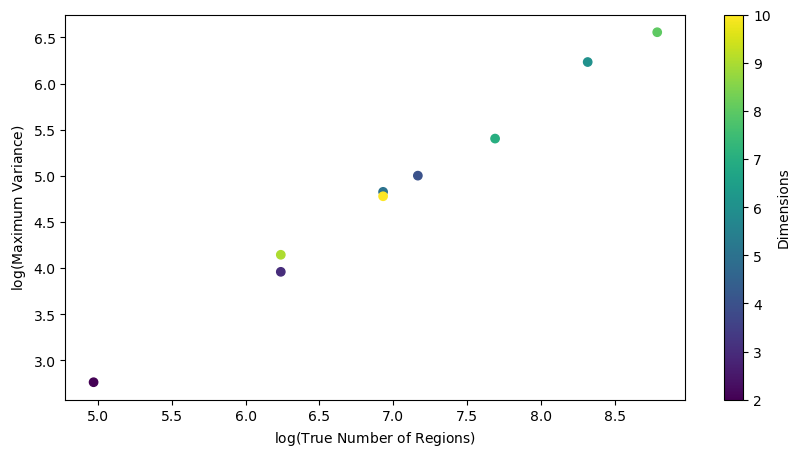

In [188]:
plt.figure(figsize=(10,5))
plt.scatter(np.log(true_count),np.log(maximum_uniform_variances_c),c=all_dimensions,cmap="viridis")
plt.colorbar(label="Dimensions")
plt.xlabel(r"$\log(\text{True Number of Regions})$")
plt.ylabel(r"$\log(\text{Maximum Variance})$")

So the simulation tells us that $\sigma^2_{\max} \approx 0.11 L$

Theory tells us that the maximum variance is given by:

$\sigma^2_{\text{max}} = L \frac{\lambda}{1+2 \lambda}$ with $e^{\lambda} = 1 + 2 \lambda$

Numerically solving to get a numerical value for $\lambda$ gives:

In [189]:
def f(x):
    return np.exp(x) - 1 - 2*x

In [192]:
x = scipy.optimize.fsolve(f,x0=1)

In [193]:
constant = x/(1+2*x)**2

In [194]:
print(constant)

[0.10181609]


Then we have $\sigma^2_{\max} \approx 0.10L$ which is roughly what we saw in our simulation

2. Uniform/Halton/Sobol/Blue Noise/Grid Comparison Graphs

- Difference in region count between method and uniform against sample size for dimensions 2,4,6,8
- Standard deviation against sample size for dimensions 2,4,6,8

HALTON:

In [196]:
num_points = 50000
all_dimensions = [2,3,4,5,6,7,8,9,10]
runs = 100
seed = 1
hidden_neurons = 24

halton_counts_c = np.empty((max(all_dimensions),runs,num_points))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = halton_sample(num_points,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region susing those point sets and assign to the appropriate part of iid_counts
    unique_counts, samples_by_region = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="online")
    unique_counts = unique_counts.detach().numpy()
    halton_counts_c[dimensions-2,:,:] = unique_counts

SOBOL:

In [199]:
all_dimensions = [2,3,4,5,6,7,8,9,10]
sample_sizes = [2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]
runs = 100
hidden_neurons = 24
seed=1

sobol_counts_c = np.empty((max(all_dimensions),runs,len(sample_sizes)))

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts, samples_by_region = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    sobol_counts_c[dimensions-2,:,:] = unique_counts

BLUE NOISE:

In [200]:
hidden_neurons = 24
runs = 100
all_dimensions = [2,3,4,5,6,7,8,9,10]

# Load point sets and get them into the right format
path = '/Users/gautamchauhan/Desktop/MSc Project Code/blue_noise_points_100_runs'
lower_bound = 0
upper_bound = 1

blue_noise_sets = load_blue_noise_points(path,lower_bound,upper_bound)

blue_noise_counts_c = np.empty((max(all_dimensions),runs,len(blue_noise_sets[0])))

for dimensions in all_dimensions:

    # Pick out the sample points corresponding to the dimension
    sample_points = blue_noise_sets[dimensions-2]

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts, samples_by_region = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    blue_noise_counts_c[dimensions-2,:,:] = unique_counts

GRID:

In [201]:
hidden_neurons = 24
all_dimensions = [2,3,4,5,6,7,8,9,10]
# For each dimension, generate up to 50000 points in a regular grid 
points_per_axis = [np.arange(2,np.ceil(50000**(1/d))) for d in all_dimensions]
lower_bound = 1e-10
upper_bound = 1-1e-10

grid_counts_c = []

for dimensions in all_dimensions:

    # Pick out the sample points corresponding to the dimension
    sample_points = points_per_axis[dimensions-2]
    grid_points = grid_sample(sample_points,dimensions,lower_bound,upper_bound)

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts, samples_by_region = experiment_2(grid_points,hidden_neurons,dimensions,runs,mode="offline")
    unique_counts = unique_counts.detach().numpy()
    grid_counts_c.append(unique_counts)

In [202]:
halton_mean_c = np.mean(halton_counts_c,axis=1)
halton_variances_c = np.var(halton_counts_c,axis=1)

In [203]:
sobol_mean_c = np.mean(sobol_counts_c,axis=1)
sobol_variances_c = np.var(sobol_counts_c,axis=1)

In [204]:
blue_noise_mean_c = np.mean(blue_noise_counts_c,axis=1)
blue_noise_variances_c = np.var(blue_noise_counts_c,axis=1)

In [205]:
blue_noise_sample_sizes = [2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]

In [206]:
sample_sizes = [2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]

Bias Graphs:

2D:

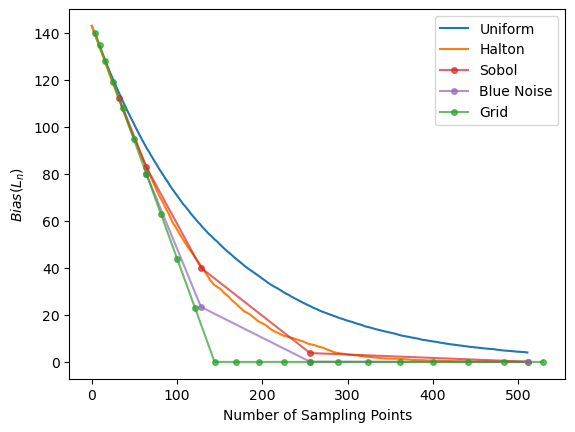

In [211]:
x = np.arange(1000000)
grid_sizes = [int(size) for size in points_per_axis[0][:22]**2]
plt.plot(x[:2**9],144-uniform_mean_c[0,:][:2**9],label="Uniform",color="tab:blue")
plt.plot(x[:2**9],144-halton_mean_c[0,:][:2**9],label="Halton",color="tab:orange")
plt.plot(sample_sizes[:5],144-sobol_mean_c[0,:][:5],marker="o",color="tab:red",label="Sobol",markersize=4,alpha=0.7)
plt.plot(blue_noise_sample_sizes[:4],144-blue_noise_mean_c[0,:][:4],marker="o",
             color="tab:purple",label="Blue Noise",markersize=4,alpha=0.7)
plt.plot(grid_sizes,144-grid_counts_c[0][0][:22],
         alpha=0.7,color="tab:green",marker="o",label="Grid",markersize=4)
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$Bias(L_n)$")
plt.legend()

4D:

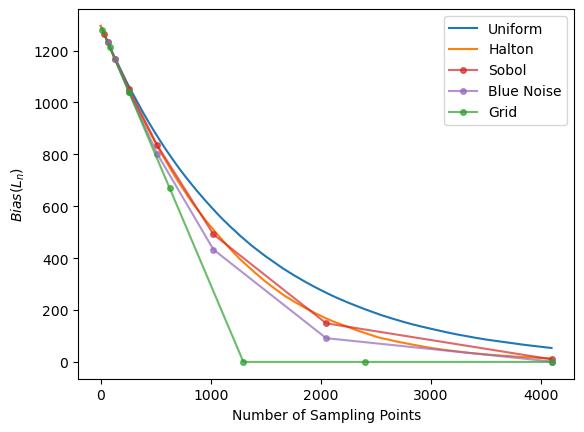

In [212]:
x = np.arange(1000000)
grid_sizes = [int(size) for size in points_per_axis[2]**4][:-6]
plt.plot(x[:2**12],1296-uniform_mean_c[2,:][:2**12],label="Uniform")
plt.plot(x[:2**12],1296-halton_mean_c[2,:][:2**12],label="Halton",color="tab:orange")
plt.plot(sample_sizes[:8],1296-sobol_mean_c[2,:][:8],marker="o",color="tab:red",label="Sobol",markersize=4,alpha=0.7)
plt.plot(blue_noise_sample_sizes[:7],1296-blue_noise_mean_c[2,:][:7],marker="o",
             color="tab:purple",label="Blue Noise",markersize=4,alpha=0.7)
plt.plot(grid_sizes,1296-grid_counts_c[2][0][:-6],color="tab:green",alpha=0.7,label="Grid",marker="o",markersize=4)
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$Bias(L_n)$")
plt.legend()

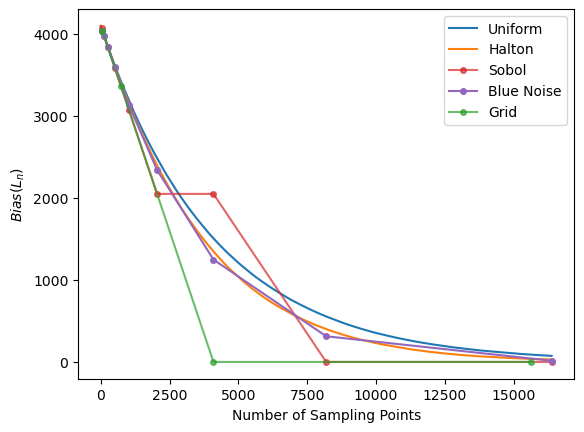

In [213]:
x = np.arange(1000000)
grid_sizes = [int(size) for size in points_per_axis[4]**6][:-1]
plt.plot(x[:2**14],4096-uniform_mean_c[4,:][:2**14],label="Uniform")
plt.plot(x[:2**14],4096-halton_mean_c[4,:][:2**14],label="Halton")
plt.plot(sample_sizes[:10],4096-sobol_mean_c[4,:][:10],marker="o",color="tab:red",label="Sobol",markersize=4,alpha=0.7)
plt.plot(blue_noise_sample_sizes[:9],4096-blue_noise_mean_c[4,:][:9],marker="o",
             color="tab:purple",label="Blue Noise",markersize=4)
plt.plot(grid_sizes,4096-grid_counts_c[4][0][:-1],alpha=0.7,color="tab:green",label="Grid",marker="o",markersize=4)
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$Bias(L_n)$")
plt.legend()

8D:

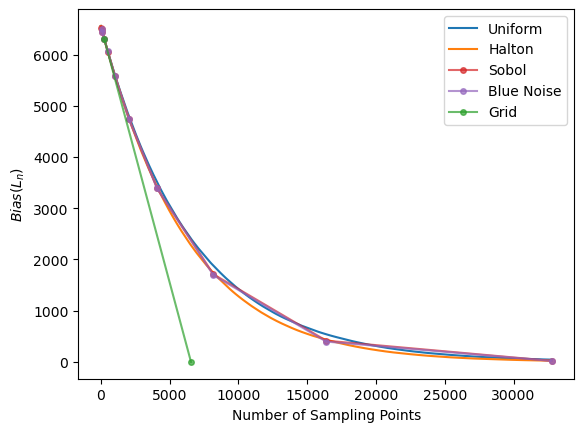

In [214]:
x = np.arange(1000000)
grid_sizes = [int(size) for size in points_per_axis[6]**8]
plt.plot(x[:2**15],6561-uniform_mean_c[6,:][:2**15],label="Uniform")
plt.plot(x[:2**15],6561-halton_mean_c[6,:][:2**15],label="Halton",color="tab:orange")
plt.plot(sample_sizes[:11],6561-sobol_mean_c[6,:][:11],marker="o",color="tab:red",label="Sobol",markersize=4,alpha=0.7)
plt.plot(blue_noise_sample_sizes[:10],6561-blue_noise_mean_c[6,:][:10],marker="o",
             color="tab:purple",label="Blue Noise",markersize=4,alpha=0.7)
plt.plot(grid_sizes, 6561-grid_counts_c[6][0],alpha=0.7,color="tab:green",label="Grid",marker="o",markersize=4)
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$Bias(L_n)$")
plt.legend()

Standard deviation graphs:

2D:

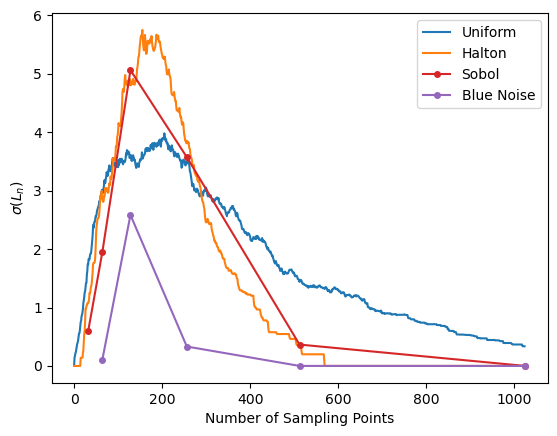

In [215]:
x = np.arange(1000000)
plt.plot(x[:2**10],np.sqrt(uniform_variances_c[0,:][:2**10]),color="tab:blue",label="Uniform")
plt.plot(x[:2**10],np.sqrt(halton_variances_c[0,:][:2**10]),label="Halton",color="tab:orange")
plt.plot(sample_sizes[:6],np.sqrt(sobol_variances_c[0,:][:6]),marker="o",color="tab:red",label="Sobol",markersize=4)
plt.plot(blue_noise_sample_sizes[:5],np.sqrt(blue_noise_variances_c[0,:][:5]),marker="o",
             color="tab:purple",label="Blue Noise",markersize=4)
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$\sigma(L_n)$")
plt.legend()

4D:

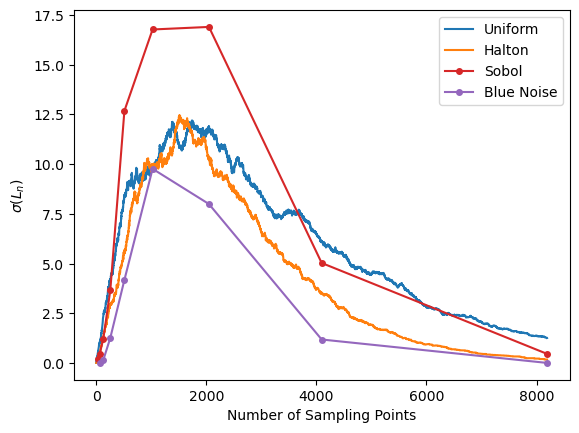

In [216]:
x = np.arange(1000000)
plt.plot(x[:2**13],np.sqrt(uniform_variances_c[2,:][:2**13]),color="tab:blue",label="Uniform")
plt.plot(x[:2**13],np.sqrt(halton_variances_c[2,:][:2**13]),label="Halton",color="tab:orange")
plt.plot(sample_sizes[:9],np.sqrt(sobol_variances_c[2,:][:9]),marker="o",color="tab:red",label="Sobol",markersize=4)
plt.plot(blue_noise_sample_sizes[:8],np.sqrt(blue_noise_variances_c[2,:][:8]),marker="o",
             color="tab:purple",label="Blue Noise",markersize=4)
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$\sigma(L_n)$")
plt.legend()

6D:

In [643]:
sample_sizes = [2**5, 2**6, 2**7, 2**8, 2**9, 2**10, 2**11, 2**12, 2**13, 2**14, 2**15]

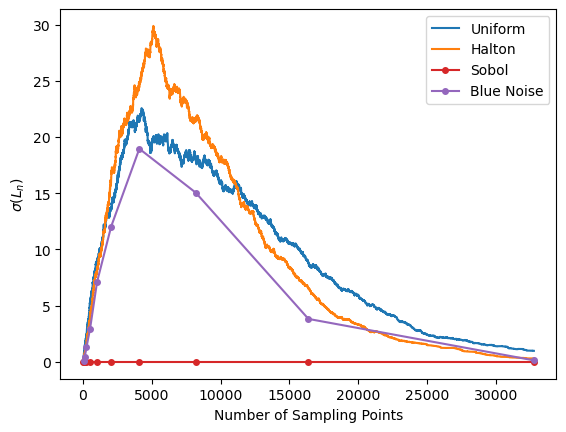

In [217]:
x = np.arange(1000000)
plt.plot(x[:2**15],np.sqrt(uniform_variances_c[4,:][:2**15]),color="tab:blue",label="Uniform")
plt.plot(x[:2**15],np.sqrt(halton_variances_c[4,:][:2**15]),label="Halton",color="tab:orange")
plt.plot(sample_sizes[:11],np.sqrt(sobol_variances_c[4,:][:11]),marker="o",color="tab:red",label="Sobol",markersize=4)
plt.plot(blue_noise_sample_sizes[:10],np.sqrt(blue_noise_variances_c[4,:][:10]),marker="o",
             color="tab:purple",label="Blue Noise",markersize=4)
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$\sigma(L_n)$")
plt.legend()

8D:

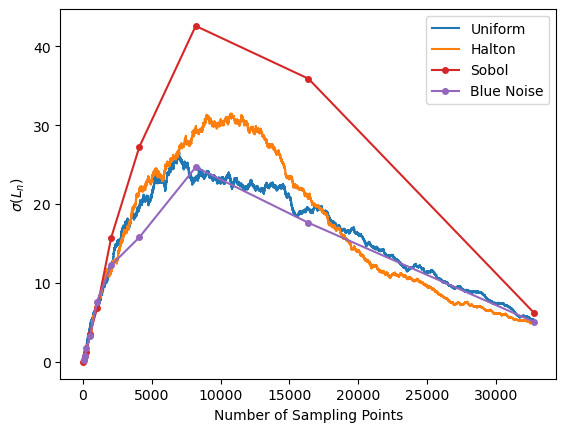

In [218]:
x = np.arange(1000000)
plt.plot(x[:2**15],np.sqrt(uniform_variances_c[6,:][:2**15]),color="tab:blue",label="Uniform")
plt.plot(x[:2**15],np.sqrt(halton_variances_c[6,:][:2**15]),label="Halton",color="tab:orange")
plt.plot(sample_sizes[:11],np.sqrt(sobol_variances_c[6,:][:11]),marker="o",color="tab:red",label="Sobol",markersize=4)
plt.plot(blue_noise_sample_sizes[:10],np.sqrt(blue_noise_variances_c[6,:][:10]),marker="o",
             color="tab:purple",label="Blue Noise",markersize=4)
plt.xlabel("Number of Sampling Points")
plt.ylabel(r"$\sigma(L_n)$")
plt.legend()

Visualise what the regions look like in the $xy$ plane for different dimensions (using blue noise samples):

In [219]:
hidden_neurons = 24
runs = 100
all_dimensions = [2]

# Load point sets and get them into the right format
path = '/Users/gautamchauhan/Desktop/MSc Project Code/blue_noise_points_100_runs'
lower_bound = 0
upper_bound = 1

blue_noise_sets = load_blue_noise_points(path,lower_bound,upper_bound)

blue_noise_counts_visualisation = np.empty((max(all_dimensions),runs,len(blue_noise_sets[0])))

for dimensions in all_dimensions:

    # Pick out the sample points corresponding to the dimension
    sample_points = blue_noise_sets[dimensions-2]

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts,samples_by_region = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="offline",return_samples=True)
    unique_counts = unique_counts.detach().numpy()
    blue_noise_counts_visualisation[dimensions-2,:,:] = unique_counts

2D looks like:

Text(0, 0.5, 'y')

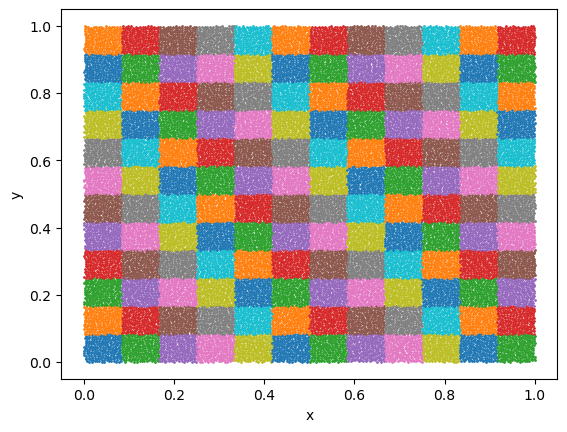

In [221]:
for key in samples_by_region:
    plt.scatter(samples_by_region[key][:,0],samples_by_region[key][:,1],s=1)
plt.xlabel("x")
plt.ylabel("y")

4D looks like:

In [227]:
hidden_neurons = 24
runs = 100
all_dimensions = [4]

# Load point sets and get them into the right format
path = '/Users/gautamchauhan/Desktop/MSc Project Code/blue_noise_points_100_runs'
lower_bound = 0
upper_bound = 1

blue_noise_sets = load_blue_noise_points(path,lower_bound,upper_bound)

blue_noise_counts_visualisation_2 = np.empty((max(all_dimensions),runs,len(blue_noise_sets[0])))

for dimensions in all_dimensions:

    # Pick out the sample points corresponding to the dimension
    sample_points = blue_noise_sets[dimensions-2]

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts,samples_by_region_2 = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="offline",return_samples=True)
    unique_counts = unique_counts.detach().numpy()
    blue_noise_counts_visualisation_2[dimensions-2,:,:] = unique_counts

Text(0, 0.5, 'y')

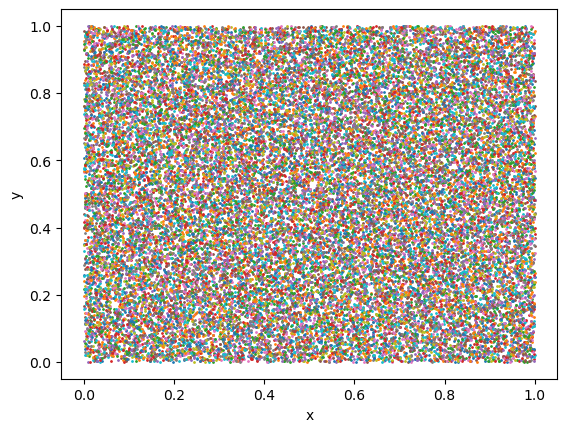

In [230]:
for key in samples_by_region_2.keys():
    plt.scatter(samples_by_region_2[key][:,0],samples_by_region_2[key][:,1],s=1)
plt.xlabel("x")
plt.ylabel("y")

#### Investigation into Sobol Behaviour

In [57]:
for i in range(2,11):
    print(np.floor(24/i),np.floor(24/i)**i,sep="\t")

12.0	144.0
8.0	512.0
6.0	1296.0
4.0	1024.0
4.0	4096.0
3.0	2187.0
3.0	6561.0
2.0	512.0
2.0	1024.0


In [231]:
all_dimensions = [2,3,4,5,6,7,8,9,10]
sample_sizes = [2**5,2**6,2**7,2**8,2**9,2**10,2**11,2**12,2**13,2**14,2**15]
runs = 100
hidden_neurons = 24
seed=1

sobol_counts_experimental = np.empty((max(all_dimensions)-1,runs,len(sample_sizes)))

all_samples_by_region_experimental = []

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds,seed)

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts,samples_by_region = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="offline",return_samples=True)
    unique_counts = unique_counts.detach().numpy()
    sobol_counts_experimental[dimensions-2,:,:] = unique_counts
    all_samples_by_region_experimental.append(samples_by_region)

1. Plot the shape of the bias graphs in each dimension:

In [232]:
sobol_mean_experimental = np.mean(sobol_counts_experimental,axis=1)
sobol_variances_experimental = np.var(sobol_counts_experimental,axis=1)

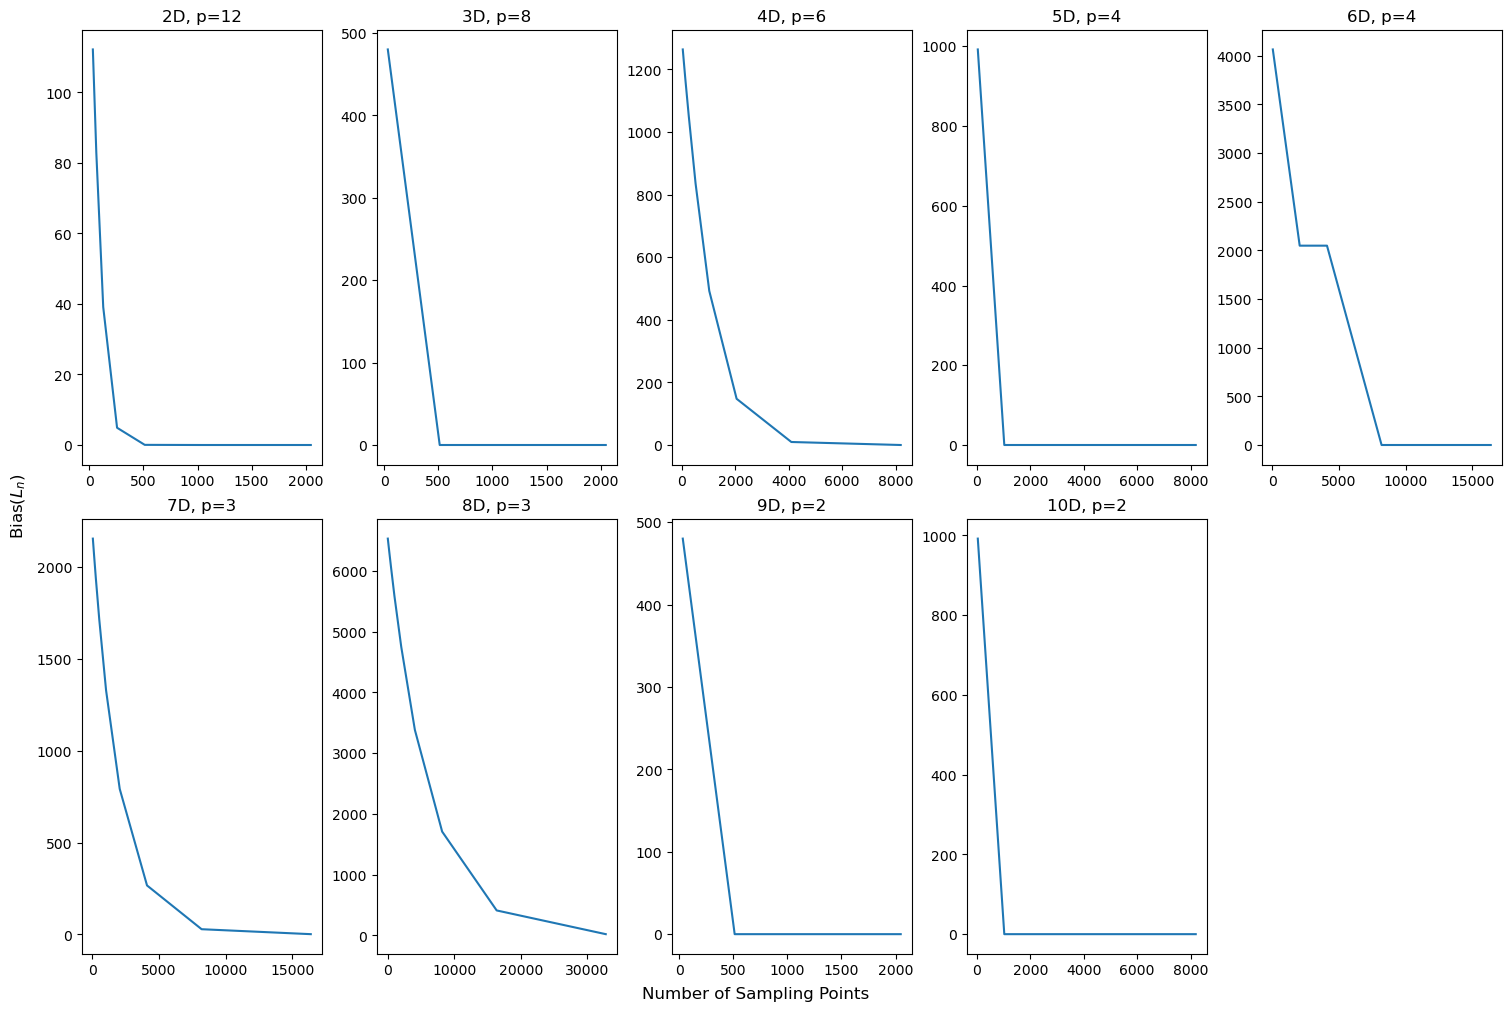

In [246]:
fig,axs = plt.subplots(2,5,figsize=(15,10),layout="constrained")

axs[0,0].plot(sample_sizes[:7],144-sobol_mean[0,:7])
axs[0,0].set_title("2D, p=12")
axs[0,1].plot(sample_sizes[:7],512-sobol_mean[1,:7])
axs[0,1].set_title("3D, p=8")
axs[0,2].plot(sample_sizes[:9],1296-sobol_mean[2,:9])
axs[0,2].set_title("4D, p=6")
axs[0,3].plot(sample_sizes[:9],1024-sobol_mean[3,:9])
axs[0,3].set_title("5D, p=4")
axs[0,4].plot(sample_sizes[:10],4096-sobol_mean[4,:10])
axs[0,4].set_title("6D, p=4")
axs[1,0].plot(sample_sizes[:10],2187-sobol_mean[5,:10])
axs[1,0].set_title("7D, p=3")
axs[1,1].plot(sample_sizes[:15],6561-sobol_mean[6,:15])
axs[1,1].set_title("8D, p=3")
axs[1,2].plot(sample_sizes[:7],512-sobol_mean[7,:7])
axs[1,2].set_title("9D, p=2")
axs[1,3].plot(sample_sizes[:9],1024-sobol_mean[8,:9])
axs[1,3].set_title("10D, p=2")

fig.supxlabel("Number of Sampling Points")
fig.supylabel(r"Bias$(L_n)$")

fig.delaxes(axs[1,4])

2. Plot shape of standard deviation graphs:

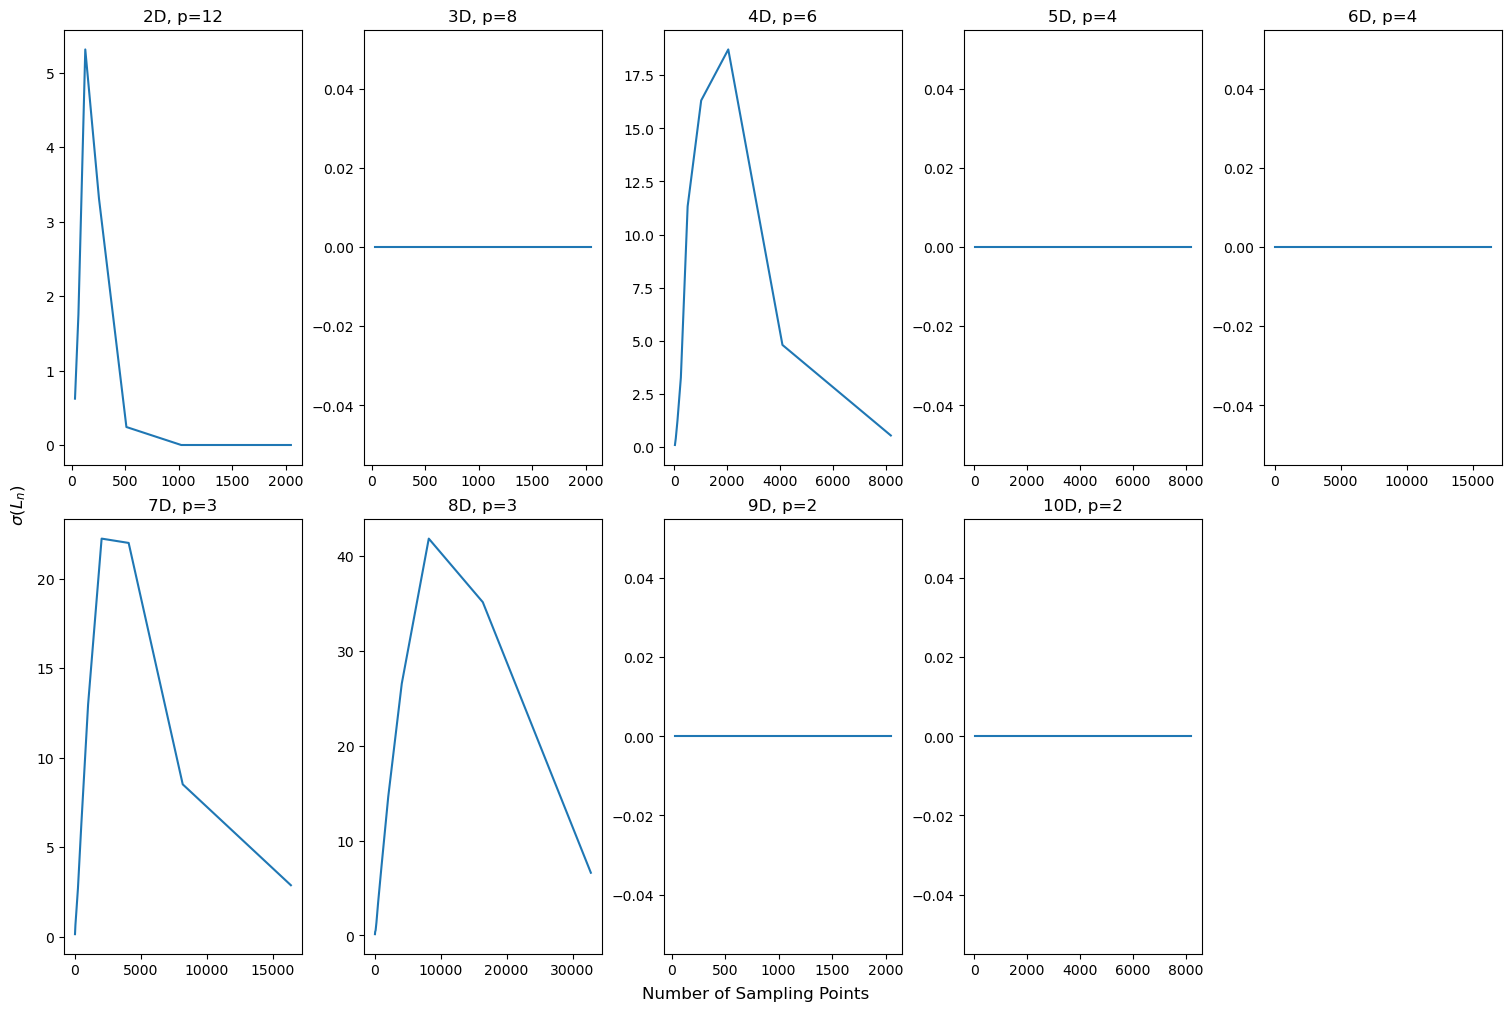

In [247]:
fig,axs = plt.subplots(2,5,figsize=(15,10),layout="constrained")

axs[0,0].plot(sample_sizes[:7],np.sqrt(sobol_variances[0,:7]))
axs[0,0].set_title("2D, p=12")
axs[0,1].plot(sample_sizes[:7],np.sqrt(sobol_variances[1,:7]))
axs[0,1].set_title("3D, p=8")
axs[0,2].plot(sample_sizes[:9],np.sqrt(sobol_variances[2,:9]))
axs[0,2].set_title("4D, p=6")
axs[0,3].plot(sample_sizes[:9],np.sqrt(sobol_variances[3,:9]))
axs[0,3].set_title("5D, p=4")
axs[0,4].plot(sample_sizes[:10],np.sqrt(sobol_variances[4,:10]))
axs[0,4].set_title("6D, p=4")
axs[1,0].plot(sample_sizes[:10],np.sqrt(sobol_variances[5,:10]))
axs[1,0].set_title("7D, p=3")
axs[1,1].plot(sample_sizes[:15],np.sqrt(sobol_variances[6,:15]))
axs[1,1].set_title("8D, p=3")
axs[1,2].plot(sample_sizes[:7],np.sqrt(sobol_variances[7,:7]))
axs[1,2].set_title("9D, p=2")
axs[1,3].plot(sample_sizes[:9],np.sqrt(sobol_variances[8,:9]))
axs[1,3].set_title("10D, p=2")

fig.supxlabel("Number of Sampling Points")
fig.supylabel(r"$\sigma(L_n)$")

fig.delaxes(axs[1,4])

Two different types of behaviour:
- Property A of sobol sequences guarantees that for a sequence of length $2^d$, if the unit hypercube is divided into $2^d$ smaller cubes, then there will be one sample in each small cube. So until all the regions have been counted, each sample finds a new region, which causes the number of regions to go straight down to 0 like the grid. Also, this property is preserved by the scrambling algorithm, so this happens for every scrambled sequence, meaning there is no variance.

- This doesn't explain why in dimension 6, we have overlap between $n=2048$ and $n=4096$, but this might be a numerical issue or because the scrambling algorithm doesn't perfectly preserve the property. The second set of points might be just off the boundary -> plot distance to the nearest boundary in dimension 6?
  
- When $p$ is not a power of 2, we don't have a power of 2 divisions along each axis, so the number of cubes is not a power of 2. This means that property A can't help us to have one point in each region, and it behaves more like the Halton sequence.

3. Plot distance to the nearest boundary in dimension 6:

In [138]:
sample_sizes = [5]
dimensions = 6
lower_bound = 0
upper_bound = 1

hypercube_boundaries = grid_sample(sample_sizes, dimensions, lower_bound, upper_bound)[0][0]

In [139]:
hypercube_boundaries.shape

torch.Size([15625, 6])

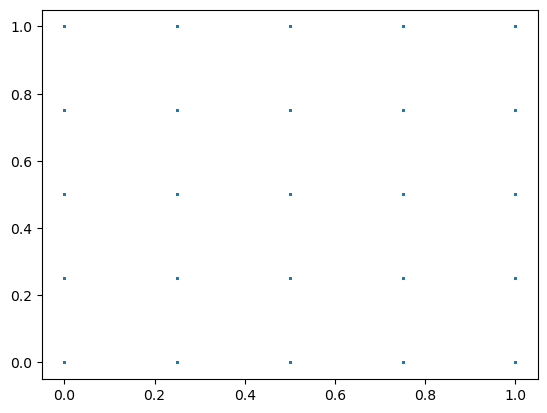

In [141]:
plt.scatter(hypercube_boundaries[:,0],hypercube_boundaries[:,1],s=1)

In [133]:
all_dimensions = [6]
sample_sizes = [4096]
runs = 100
hidden_neurons = 24

sobol_counts_experimental = np.empty((max(all_dimensions)-1,runs,len(sample_sizes)))

all_samples_by_region_experimental = []

for dimensions in all_dimensions:

    # Generate point set
    lower_bounds = np.full(dimensions,0)
    upper_bounds = np.full(dimensions,1)
    sample_points = sobol_sample(sample_sizes,dimensions,runs,lower_bounds,upper_bounds)

    # Count linear region using those point sets and assign to the appropriate part of iid_counts
    unique_counts,samples_by_region = experiment_2(sample_points,hidden_neurons,dimensions,runs,mode="offline",return_samples=True)
    unique_counts = unique_counts.detach().numpy()
    sobol_counts_experimental[dimensions-2,:,:] = unique_counts
    all_samples_by_region_experimental.append(samples_by_region)

In [147]:
distances = []
for key in samples_by_region.keys():
    for point in samples_by_region[key]:
        distance_matrix = torch.abs(point - hypercube_boundaries)
        distances.append(torch.min(distance_matrix))

(array([389., 356., 328., 283., 259., 251., 230., 206., 185., 173., 164.,
        131., 129., 129., 101.,  89.,  87.,  66.,  79.,  57.,  48.,  44.,
         51.,  41.,  26.,  30.,  27.,  25.,  22.,  12.,  12.,  12.,  10.,
          7.,   7.,   6.,   7.,   3.,   3.,   1.,   3.,   3.,   0.,   1.,
          0.,   0.,   1.,   0.,   1.,   1.]),
 array([3.38722020e-06, 2.01664407e-03, 4.02990092e-03, 6.04315776e-03,
        8.05641461e-03, 1.00696715e-02, 1.20829283e-02, 1.40961852e-02,
        1.61094420e-02, 1.81226989e-02, 2.01359557e-02, 2.21492125e-02,
        2.41624694e-02, 2.61757262e-02, 2.81889831e-02, 3.02022399e-02,
        3.22154968e-02, 3.42287536e-02, 3.62420105e-02, 3.82552673e-02,
        4.02685242e-02, 4.22817810e-02, 4.42950379e-02, 4.63082947e-02,
        4.83215516e-02, 5.03348084e-02, 5.23480653e-02, 5.43613221e-02,
        5.63745790e-02, 5.83878358e-02, 6.04010927e-02, 6.24143495e-02,
        6.44276064e-02, 6.64408632e-02, 6.84541200e-02, 7.04673769e-02,
        7.

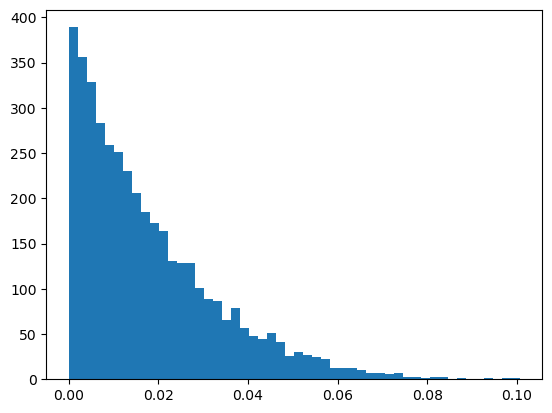

In [151]:
plt.hist(distances,bins=50)

#### Save Experiment Code Files:

In [62]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_2/iid_counts_b.npy',iid_counts)

In [63]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_2/halton_counts_b.npy',halton_counts_b)

In [410]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_2/iid_counts_c.npy',iid_counts_c)

In [411]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_2/halton_counts_c.npy',halton_counts_c)

In [250]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/scenario_1/sobol_counts_c.npy',sobol_counts_c)

In [625]:
np.save('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_2/blue_noise_counts_c.npy',blue_noise_counts_c)

In [977]:
np.savez('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_2/grid_counts_c.npz',*grid_counts_c)

Test reload:

In [978]:
grid_counts_reloaded = np.load('/Users/gautamchauhan/Desktop/MSc Project Code/experiments/experiment_2/grid_counts_c.npz',mmap_mode="r")